In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [39]:
depression= pd.read_csv('Depression_Professional_Dataset.csv')

In [40]:
depression.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No


In [41]:
depression.keys()

Index(['Gender', 'Age', 'Work Pressure', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [42]:
depression.isnull().sum()

Gender                                   0
Age                                      0
Work Pressure                            0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Work Hours                               0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [43]:
depression.dtypes

Gender                                   object
Age                                       int64
Work Pressure                             int64
Job Satisfaction                          int64
Sleep Duration                           object
Dietary Habits                           object
Have you ever had suicidal thoughts ?    object
Work Hours                                int64
Financial Stress                          int64
Family History of Mental Illness         object
Depression                               object
dtype: object

In [44]:
depression.describe()

,Age,Work Pressure,Job Satisfaction,Work Hours,Financial Stress
count,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000
mean,42.171860,3.021908,3.015093,5.930867,2.978578
std,11.461202,1.417312,1.418432,3.773945,1.413362
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,35.000000,2.000000,2.000000,3.000000,2.000000
50%,43.000000,3.000000,3.000000,6.000000,3.000000
75%,51.750000,4.000000,4.000000,9.000000,4.000000
max,60.000000,5.000000,5.000000,12.000000,5.000000


In [45]:
depression['Age'].describe()

count    2054.000000
mean       42.171860
std        11.461202
min        18.000000
25%        35.000000
50%        43.000000
75%        51.750000
max        60.000000
Name: Age, dtype: float64

In [46]:
depression['Age'].value_counts()

Age
56    73
49    72
38    71
47    66
46    64
51    63
50    63
53    63
42    63
57    62
35    61
59    61
40    61
43    59
48    59
39    59
54    59
41    57
45    57
36    56
55    51
37    51
44    51
60    50
58    49
52    46
33    36
18    36
29    35
31    35
28    34
25    32
24    32
34    32
27    31
26    30
23    29
22    28
20    28
30    27
21    24
19    21
32    17
Name: count, dtype: int64

In [47]:
depression['Work Pressure'].describe()

count    2054.000000
mean        3.021908
std         1.417312
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Work Pressure, dtype: float64

In [48]:
depression['Work Pressure'].value_counts()

Work Pressure
5    424
2    413
4    412
3    404
1    401
Name: count, dtype: int64

In [49]:
depression['Job Satisfaction'].describe()

count    2054.000000
mean        3.015093
std         1.418432
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Job Satisfaction, dtype: float64

In [50]:
depression['Job Satisfaction'].value_counts()

Job Satisfaction
5    431
2    431
3    404
1    396
4    392
Name: count, dtype: int64

In [51]:
depression['Work Hours'].describe()

count    2054.000000
mean        5.930867
std         3.773945
min         0.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        12.000000
Name: Work Hours, dtype: float64

In [52]:
depression['Work Hours'].value_counts()

Work Hours
9     177
0     170
2     169
5     166
10    165
11    164
1     162
3     155
6     153
7     150
4     148
12    145
8     130
Name: count, dtype: int64

In [53]:
depression['Financial Stress'].describe()

count    2054.000000
mean        2.978578
std         1.413362
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Financial Stress, dtype: float64

In [54]:
depression['Financial Stress'].value_counts()

Financial Stress
2    447
4    407
1    407
5    405
3    388
Name: count, dtype: int64

In [55]:
depression.median(numeric_only= True)

Age                 43.0
Work Pressure        3.0
Job Satisfaction     3.0
Work Hours           6.0
Financial Stress     3.0
dtype: float64

In [56]:
depression.mode()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,56.0,5.0,2,7-8 hours,Unhealthy,No,9.0,2.0,No,No
1,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
depression['Gender'].describe()

count     2054
unique       2
top       Male
freq      1066
Name: Gender, dtype: object

In [58]:
depression['Gender'].value_counts()

Gender
Male      1066
Female     988
Name: count, dtype: int64

In [59]:
depression['Gender'].value_counts(normalize= True)

Gender
Male      0.518987
Female    0.481013
Name: proportion, dtype: float64

In [60]:
depression['Sleep Duration'].describe()

count          2054
unique            4
top       7-8 hours
freq            530
Name: Sleep Duration, dtype: object

In [61]:
depression['Sleep Duration'].value_counts()

Sleep Duration
7-8 hours            530
Less than 5 hours    525
5-6 hours            505
More than 8 hours    494
Name: count, dtype: int64

In [62]:
depression['Sleep Duration'].value_counts(normalize= True)

Sleep Duration
7-8 hours            0.258033
Less than 5 hours    0.255599
5-6 hours            0.245862
More than 8 hours    0.240506
Name: proportion, dtype: float64

In [63]:
depression['Dietary Habits'].describe()

count          2054
unique            3
top       Unhealthy
freq            713
Name: Dietary Habits, dtype: object

In [64]:
depression['Dietary Habits'].value_counts()

Dietary Habits
Unhealthy    713
Healthy      681
Moderate     660
Name: count, dtype: int64

In [65]:
depression['Dietary Habits'].value_counts(normalize= True)

Dietary Habits
Unhealthy    0.347128
Healthy      0.331548
Moderate     0.321324
Name: proportion, dtype: float64

In [66]:
depression['Have you ever had suicidal thoughts ?'].describe()

count     2054
unique       2
top         No
freq      1065
Name: Have you ever had suicidal thoughts ?, dtype: object

In [67]:
depression['Have you ever had suicidal thoughts ?'].value_counts()

Have you ever had suicidal thoughts ?
No     1065
Yes     989
Name: count, dtype: int64

In [68]:
depression['Have you ever had suicidal thoughts ?'].value_counts(normalize= True)

Have you ever had suicidal thoughts ?
No     0.5185
Yes    0.4815
Name: proportion, dtype: float64

In [69]:
depression['Family History of Mental Illness'].describe()

count     2054
unique       2
top         No
freq      1046
Name: Family History of Mental Illness, dtype: object

In [70]:
depression['Family History of Mental Illness'].value_counts()

Family History of Mental Illness
No     1046
Yes    1008
Name: count, dtype: int64

In [71]:
depression['Family History of Mental Illness'].value_counts(normalize= True)

Family History of Mental Illness
No     0.50925
Yes    0.49075
Name: proportion, dtype: float64

In [72]:
depression['Depression'].describe()

count     2054
unique       2
top         No
freq      1851
Name: Depression, dtype: object

In [73]:
depression['Depression'].value_counts()

Depression
No     1851
Yes     203
Name: count, dtype: int64

In [74]:
depression['Depression'].value_counts(normalize= True)

Depression
No     0.901168
Yes    0.098832
Name: proportion, dtype: float64

<Axes: >

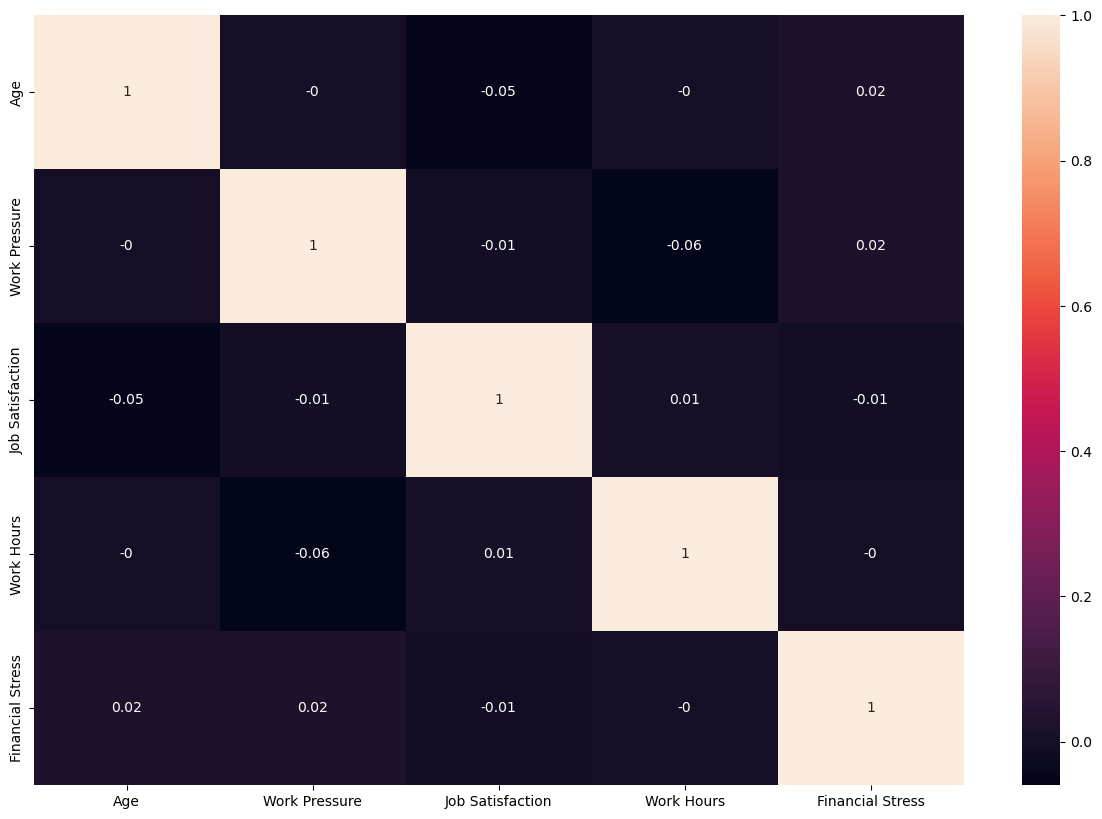

In [75]:
corr = depression.corr(numeric_only=True).round(2)
plt.figure(figsize = (15,10))
sns.heatmap(corr, annot = True)

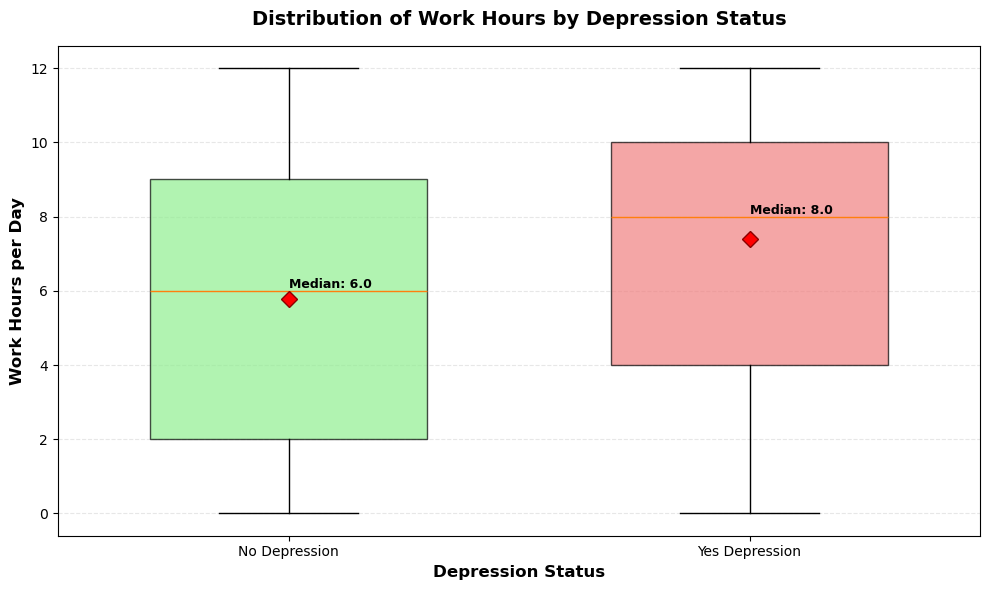

In [76]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
no_dep = depression[depression['Depression'] == 'No']['Work Hours']
yes_dep = depression[depression['Depression'] == 'Yes']['Work Hours']
data_groups = [no_dep, yes_dep]

# Create box plot
bp = ax.boxplot(data_groups, 
                tick_labels=['No Depression', 'Yes Depression'],
                patch_artist=True,
                widths=0.6,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=8,
                             markeredgecolor='darkred'))

# Customize appearance
colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add median labels
for i, data in enumerate(data_groups):
    median_val = data.median()
    ax.text(i+1, median_val, f'Median: {median_val:.1f}', 
            ha='left', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Work Hours per Day', fontweight='bold', fontsize=12)
ax.set_xlabel('Depression Status', fontweight='bold', fontsize=12)
ax.set_title('Distribution of Work Hours by Depression Status', 
            fontweight='bold', fontsize=14, pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

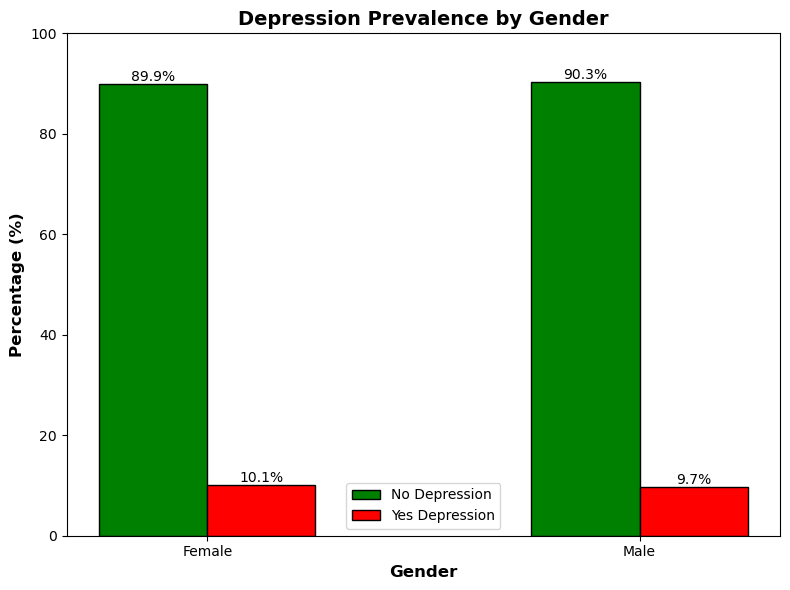

In [77]:
plt.figure(figsize=(8, 6))

# Calculate percentages for each gender
gender_stats = depression.groupby(['Gender', 'Depression']).size().unstack(fill_value=0)
gender_percentages = gender_stats.div(gender_stats.sum(axis=1), axis=0) * 100

# Plot grouped bars
x = np.arange(len(gender_percentages.index))
width = 0.25

bars1 = plt.bar(x - width/2, gender_percentages['No'], width, 
                label='No Depression', color='Green', edgecolor='black')
bars2 = plt.bar(x + width/2, gender_percentages['Yes'], width,
                label='Yes Depression', color='Red', edgecolor='black')

# Add labels and formatting
plt.xlabel('Gender', fontweight='bold', fontsize=12)
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.title('Depression Prevalence by Gender', fontweight='bold', fontsize=14)
plt.xticks(x, gender_percentages.index)
plt.legend()
plt.ylim(0, 100)

# Add percentage labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


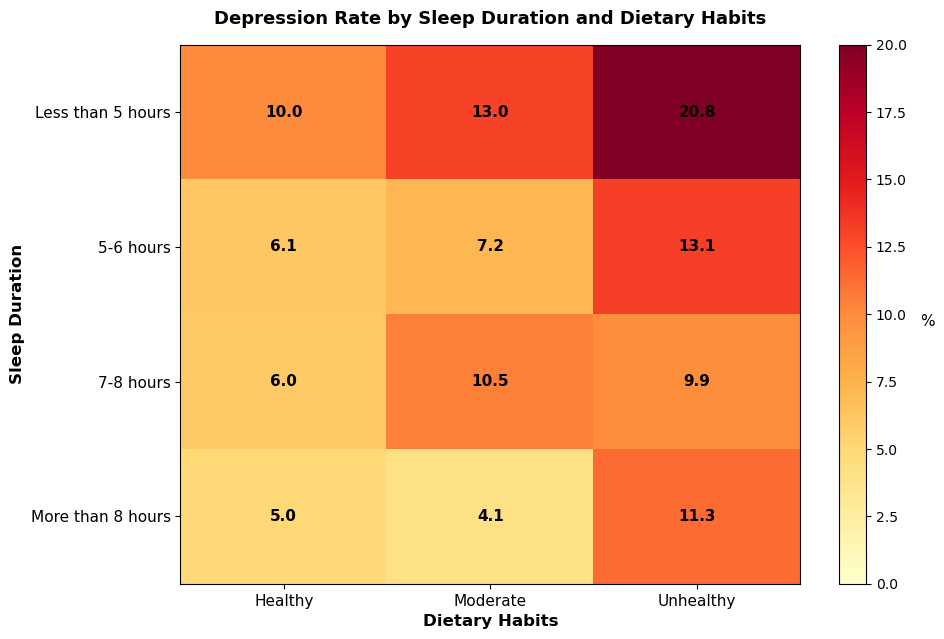

In [78]:
plt.figure(figsize=(10, 7))

sleep_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
diet_order = ['Healthy', 'Moderate', 'Unhealthy']

# Calculate depression rates for each combination
combined = depression.groupby(['Sleep Duration', 'Dietary Habits'])['Depression'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).unstack()

combined = combined.reindex(sleep_order)[diet_order]

# Create heatmap
im = plt.imshow(combined.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=20)

plt.xticks(range(len(diet_order)), diet_order, fontsize=11)
plt.yticks(range(len(sleep_order)), sleep_order, fontsize=11)
plt.xlabel('Dietary Habits', fontweight='bold', fontsize=12)
plt.ylabel('Sleep Duration', fontweight='bold', fontsize=12)
plt.title('Depression Rate by Sleep Duration and Dietary Habits', 
          fontweight='bold', fontsize=13, pad=15)

# Add values in cells
for i in range(len(sleep_order)):
    for j in range(len(diet_order)):
        value = combined.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f'{value:.1f}',
                    ha="center", va="center",
                    color="black" if value < 35 else "white", 
                    fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, label='%')
cbar.set_label('%', rotation=0, labelpad=15, fontsize=11)

plt.show()


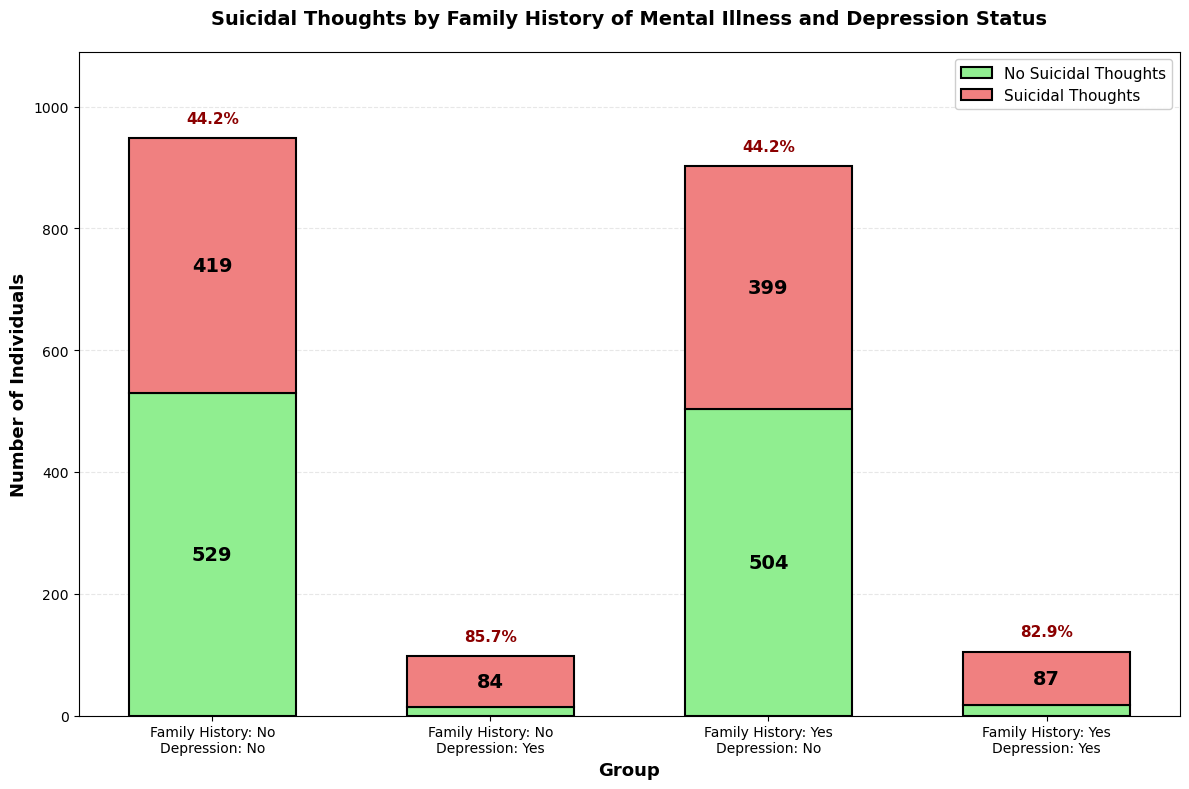

In [80]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))

# Create four groups
groups = [
    ('No', 'No'),   # Family History: No, Depression: No
    ('No', 'Yes'),  # Family History: No, Depression: Yes
    ('Yes', 'No'),  # Family History: Yes, Depression: No
    ('Yes', 'Yes')  # Family History: Yes, Depression: Yes
]

group_labels = [
    'Family History: No\nDepression: No',
    'Family History: No\nDepression: Yes',
    'Family History: Yes\nDepression: No',
    'Family History: Yes\nDepression: Yes'
]

# Calculate counts
no_suicidal = []
yes_suicidal = []
group_totals = []

for fh, dep in groups:
    subset = depression[(depression['Family History of Mental Illness'] == fh) & 
                       (depression['Depression'] == dep)]
    no_count = (subset['Have you ever had suicidal thoughts ?'] == 'No').sum()
    yes_count = (subset['Have you ever had suicidal thoughts ?'] == 'Yes').sum()
    total = len(subset)
    no_suicidal.append(no_count)
    yes_suicidal.append(yes_count)
    group_totals.append(total)

# Create stacked bars
x = np.arange(len(groups))
width = 0.6

bars1 = ax.bar(x, no_suicidal, width, label='No Suicidal Thoughts', 
              color='lightgreen', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, yes_suicidal, width, bottom=no_suicidal, 
              label='Suicidal Thoughts', color='lightcoral', 
              edgecolor='black', linewidth=1.5)

# Add labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    if height1 > 50:
        ax.text(bar1.get_x() + bar1.get_width()/2., height1/2,
               f'{int(no_suicidal[i])}', ha='center', va='center', 
               fontsize=14, fontweight='bold')
    
    height2 = bar2.get_height()
    if height2 > 20:
        ax.text(bar2.get_x() + bar2.get_width()/2., height1 + height2/2,
               f'{int(yes_suicidal[i])}', ha='center', va='center', 
               fontsize=14, fontweight='bold')
    
    total_height = height1 + height2
    yes_percentage = yes_suicidal[i] / group_totals[i] * 100
    ax.text(bar2.get_x() + bar2.get_width()/2., total_height + 20,
           f'{yes_percentage:.1f}%', ha='center', va='bottom', 
           fontsize=11, fontweight='bold', color='darkred')

ax.set_ylabel('Number of Individuals', fontweight='bold', fontsize=13)
ax.set_xlabel('Group', fontweight='bold', fontsize=13)
ax.set_title('Suicidal Thoughts by Family History of Mental Illness and Depression Status', 
            fontweight='bold', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(group_labels, fontsize=10)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.set_ylim(0, max(group_totals) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

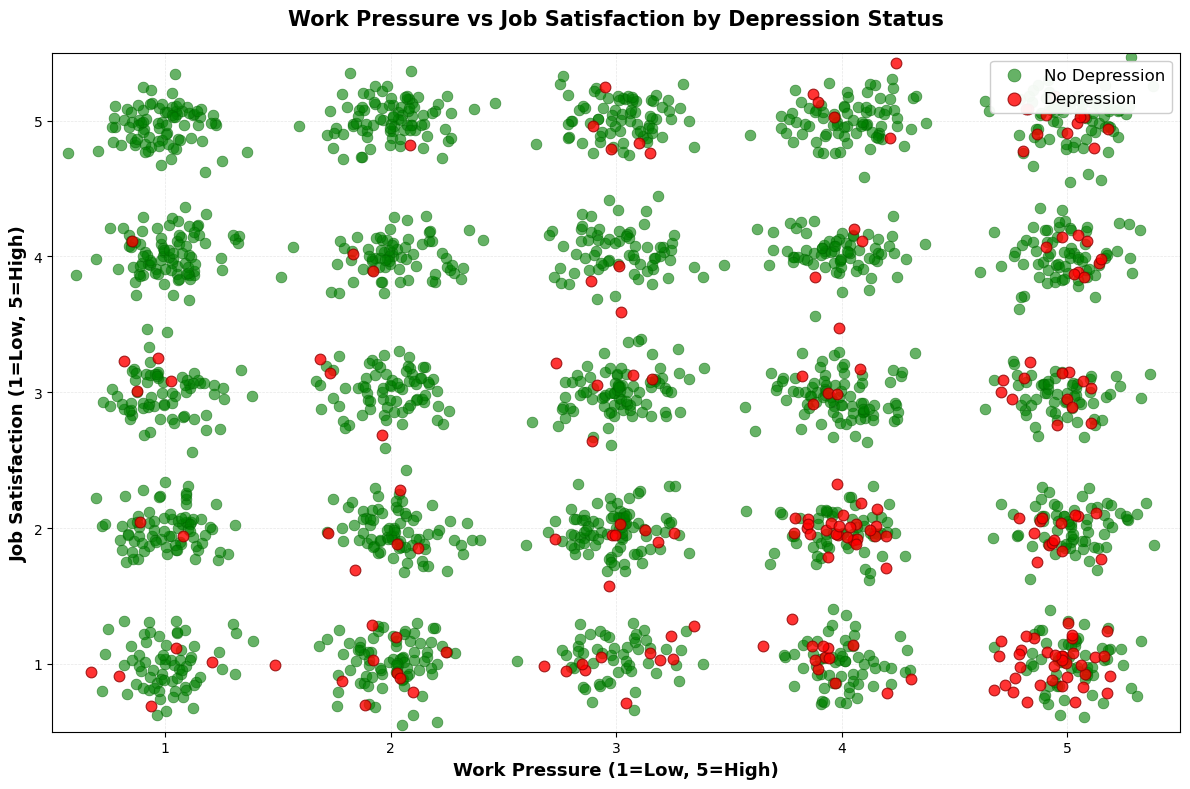

In [81]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))

# Separate by depression status
no_depression = depression[depression['Depression'] == 'No']
yes_depression = depression[depression['Depression'] == 'Yes']

# Add jitter to avoid overplotting (discrete 1-5 values)
jitter_strength = 0.15
np.random.seed(42)  # For reproducibility

# Create jittered coordinates
x_no = no_depression['Work Pressure'] + np.random.normal(0, jitter_strength, len(no_depression))
y_no = no_depression['Job Satisfaction'] + np.random.normal(0, jitter_strength, len(no_depression))
x_yes = yes_depression['Work Pressure'] + np.random.normal(0, jitter_strength, len(yes_depression))
y_yes = yes_depression['Job Satisfaction'] + np.random.normal(0, jitter_strength, len(yes_depression))

# Plot points
ax.scatter(x_no, y_no, alpha=0.6, s=60, c='green', 
          label='No Depression', edgecolors='darkgreen', linewidth=0.5)
ax.scatter(x_yes, y_yes, alpha=0.8, s=60, c='red', 
          label='Depression', edgecolors='darkred', linewidth=0.8)

# Set axis properties
ax.set_xlabel('Work Pressure (1=Low, 5=High)', fontweight='bold', fontsize=13)
ax.set_ylabel('Job Satisfaction (1=Low, 5=High)', fontweight='bold', fontsize=13)
ax.set_title('Work Pressure vs Job Satisfaction by Depression Status', 
            fontweight='bold', fontsize=15, pad=20)

# Set limits and ticks
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])

# Add grid and legend
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=12, framealpha=0.95, 
         markerscale=1.2, shadow=False)

plt.tight_layout()
plt.show()

In [352]:
# ============================================================================
# SECTION 2: TASK 2 - Classification
# ============================================================================

In [82]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
depression['Gender'] = LE.fit_transform(depression['Gender'])
depression['Sleep Duration'] = LE.fit_transform(depression['Sleep Duration'])
depression['Dietary Habits'] = LE.fit_transform(depression['Dietary Habits'])
depression['Have you ever had suicidal thoughts ?'] = LE.fit_transform(depression['Have you ever had suicidal thoughts ?'])
depression['Family History of Mental Illness'] = LE.fit_transform(depression['Family History of Mental Illness'])
depression['Depression'] = LE.fit_transform(depression['Depression'])

In [83]:
depression.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,37,2,4,1,1,0,6,2,0,0
1,1,60,4,3,0,2,1,0,4,1,0
2,0,42,2,3,0,1,0,0,2,0,0
3,0,44,3,5,1,0,1,1,2,1,0
4,1,48,4,3,1,1,1,6,5,1,0


In [47]:
depression.shape


(2054, 11)

In [48]:
X = depression.drop('Depression', axis=1)
y = depression['Depression']

In [49]:
X.shape

(2054, 10)

In [50]:
y.shape

(2054,)

In [51]:

count = Counter(y)
print(count)

Counter({0: 1851, 1: 203})


In [52]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [53]:
y_train.shape

(1643,)

In [54]:
y_test.shape

(411,)

In [65]:
# initialize the classifier
SVM = SVC(kernel = 'linear')

#fit the classifier to the data
SVM.fit(X_train,y_train)

#use the resulting model to predict value on the test sey
y_pred = SVM.predict(X_test)
print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[365   5]
 [  2  39]] 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       370
           1       0.89      0.95      0.92        41

    accuracy                           0.98       411
   macro avg       0.94      0.97      0.95       411
weighted avg       0.98      0.98      0.98       411

Accuracy: 0.9829683698296837
AUC: 0.9688529993408043


In [66]:
X_train.shape

(1643, 10)

In [79]:
#cross-validation
from sklearn.model_selection import cross_val_score
SVM1 = SVC(kernel = 'linear')

#accuracy scores for each fold
scores = cross_val_score(SVM1, X_train, y_train, cv=10)
print(scores)

#print the average accuracy across all folds
print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

[0.96969697 0.96969697 0.99393939 0.98170732 0.98780488 0.9695122
 0.98170732 0.97560976 0.9695122  0.98780488]
Accuracy: 0.98 (+/- 0.02)


In [80]:
#performance metrics

from sklearn.model_selection import cross_val_predict

#predicted values
y_pred = cross_val_predict(SVM1, X_test, y_test, cv=10)

print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[364   6]
 [  6  35]] 

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       370
           1       0.85      0.85      0.85        41

    accuracy                           0.97       411
   macro avg       0.92      0.92      0.92       411
weighted avg       0.97      0.97      0.97       411

Accuracy: 0.9708029197080292
AUC: 0.9187211601845747


In [81]:
# Dictionary to store results
results = {}

[[368   2]
 [ 16  25]] 

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       370
           1       0.93      0.61      0.74        41

    accuracy                           0.96       411
   macro avg       0.94      0.80      0.86       411
weighted avg       0.96      0.96      0.95       411

  Accuracy: 0.9562
  Precision: 0.9259
  Recall: 0.6098
  F1-Score: 0.7353
  AUC: 0.8022


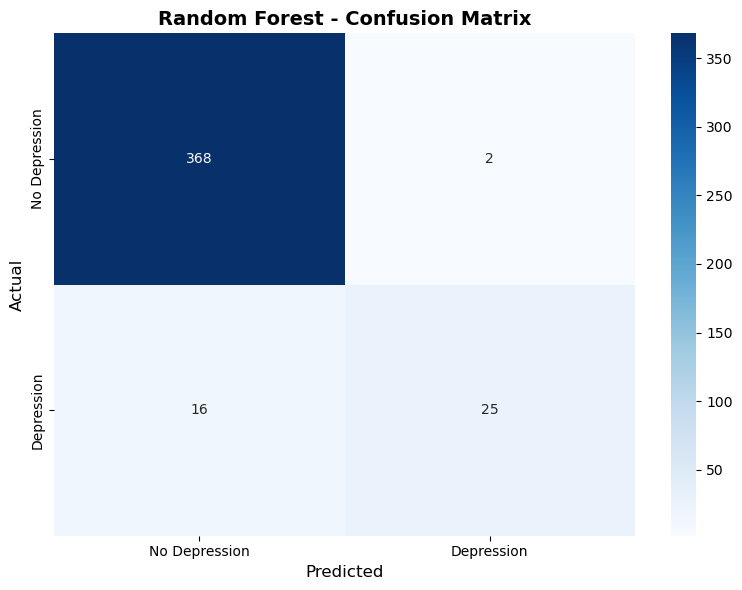

In [156]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='binary')
rf_recall = recall_score(y_test, rf_pred, average='binary')
rf_f1 = f1_score(y_test, rf_pred, average='binary')
rf_cm = confusion_matrix(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred)

# Store results
results['Random Forest'] = {
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1_score': rf_f1,
    'confusion_matrix': rf_cm,
    'predictions': rf_pred,
    'AUC_score': rf_auc
}

print( rf_cm, '\n')
print(classification_report(y_test, rf_pred))
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall: {rf_recall:.4f}")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  AUC: {rf_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()

[[351  19]
 [  0  41]] 

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       370
           1       0.68      1.00      0.81        41

    accuracy                           0.95       411
   macro avg       0.84      0.97      0.89       411
weighted avg       0.97      0.95      0.96       411

  Accuracy: 0.9538
  Precision: 0.6833
  Recall: 1.0000
  F1-Score: 0.8119
  AUC: 0.9743


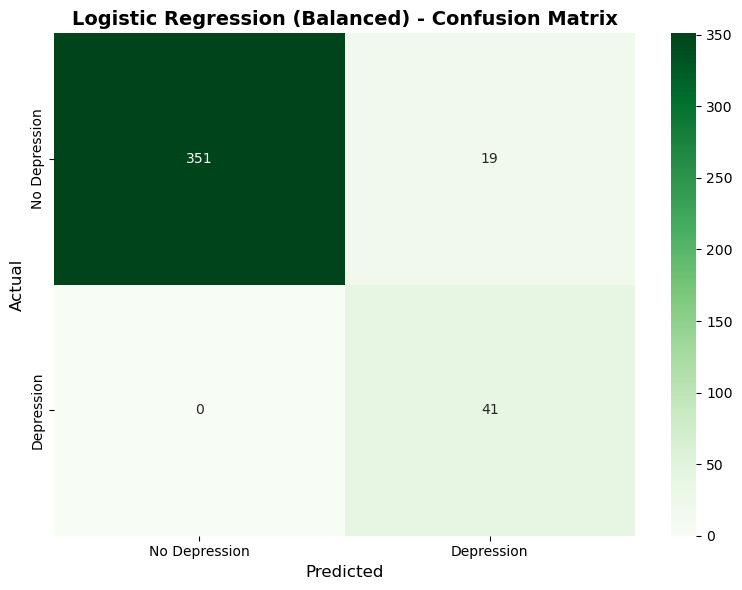

In [161]:
lrb_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

lrb_model.fit(X_train, y_train)
lrb_pred = lrb_model.predict(X_test)

# Calculate metrics
lrb_accuracy = accuracy_score(y_test, lrb_pred)
lrb_precision = precision_score(y_test, lrb_pred, average='binary')
lrb_recall = recall_score(y_test, lrb_pred, average='binary')
lrb_f1 = f1_score(y_test, lrb_pred, average='binary')
lrb_cm = confusion_matrix(y_test, lrb_pred)
lrb_auc = roc_auc_score(y_test, lrb_pred)

# Store results
results['Logistic Regression- Balanced'] = {
    'accuracy': lrb_accuracy,
    'precision': lrb_precision,
    'recall': lrb_recall,
    'f1_score': lrb_f1,
    'confusion_matrix': lrb_cm,
    'predictions': lrb_pred,
    'AUC_score': lrb_auc
}

print( lrb_cm, '\n')
print(classification_report(y_test, lrb_pred))
print(f"  Accuracy: {lrb_accuracy:.4f}")
print(f"  Precision: {lrb_precision:.4f}")
print(f"  Recall: {lrb_recall:.4f}")
print(f"  F1-Score: {lrb_f1:.4f}")
print(f"  AUC: {lrb_auc:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(lrb_cm, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Logistic Regression (Balanced) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()

[[365   5]
 [  3  38]] 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       370
           1       0.88      0.93      0.90        41

    accuracy                           0.98       411
   macro avg       0.94      0.96      0.95       411
weighted avg       0.98      0.98      0.98       411

  Accuracy: 0.9805
  Precision: 0.8837
  Recall: 0.9268
  F1-Score: 0.9048
  AUC: 0.9567


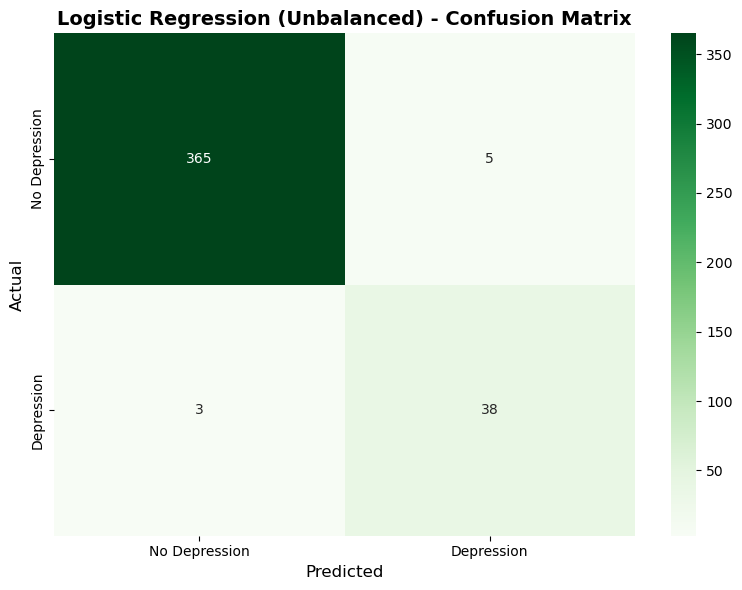

In [162]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42    
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='binary')
lr_recall = recall_score(y_test, lr_pred, average='binary')
lr_f1 = f1_score(y_test, lr_pred, average='binary')
lr_cm = confusion_matrix(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_pred)

# Store results
results['Logistic Regression'] = {
    'accuracy': lr_accuracy,
    'precision': lr_precision,
    'recall': lr_recall,
    'f1_score': lr_f1,
    'confusion_matrix': lr_cm,
    'predictions': lr_pred,
    'AUC_score': lrb_auc
}

print( lr_cm, '\n')
print(classification_report(y_test, lr_pred))
print(f"  Accuracy: {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall: {lr_recall:.4f}")
print(f"  F1-Score: {lr_f1:.4f}")
print(f"  AUC: {lr_auc:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Logistic Regression (Unbalanced) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()

[[350  20]
 [  0  41]] 

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       370
           1       0.67      1.00      0.80        41

    accuracy                           0.95       411
   macro avg       0.84      0.97      0.89       411
weighted avg       0.97      0.95      0.96       411

  Accuracy: 0.9513
  Precision: 0.6721
  Recall: 1.0000
  F1-Score: 0.8039
  AUC: 0.9730


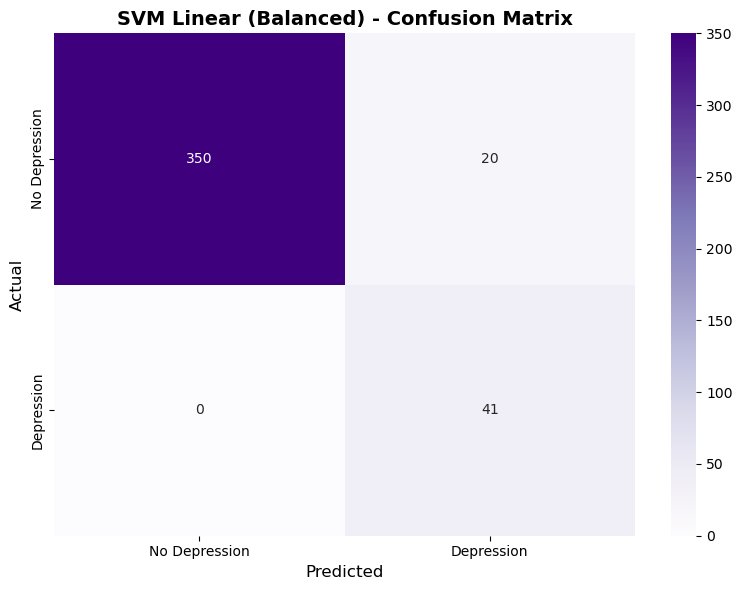

In [163]:
svmb_model = SVC(
    kernel='linear',
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

svmb_model.fit(X_train, y_train)
svmb_pred = svmb_model.predict(X_test)

# Calculate metrics
svmb_accuracy = accuracy_score(y_test, svmb_pred)
svmb_precision = precision_score(y_test, svmb_pred, average='binary')
svmb_recall = recall_score(y_test, svmb_pred, average='binary')
svmb_f1 = f1_score(y_test, svmb_pred, average='binary')
svmb_cm = confusion_matrix(y_test, svmb_pred)
svmb_auc = roc_auc_score(y_test, svmb_pred)

# Store results
results['SVM-Balanced'] = {
    'accuracy': svmb_accuracy,
    'precision': svmb_precision,
    'recall': svmb_recall,
    'f1_score': svmb_f1,
    'confusion_matrix': svmb_cm,
    'predictions': svmb_pred,
    'AUC_score': svmb_auc
}

print( svmb_cm, '\n')
print(classification_report(y_test, svmb_pred))
print(f"  Accuracy: {svmb_accuracy:.4f}")
print(f"  Precision: {svmb_precision:.4f}")
print(f"  Recall: {svmb_recall:.4f}")
print(f"  F1-Score: {svmb_f1:.4f}")
print(f"  AUC: {svmb_auc:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(svmb_cm, annot=True, fmt='d', cmap='Purples', cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('SVM Linear (Balanced) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()

[[365   5]
 [  2  39]] 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       370
           1       0.89      0.95      0.92        41

    accuracy                           0.98       411
   macro avg       0.94      0.97      0.95       411
weighted avg       0.98      0.98      0.98       411

  Accuracy: 0.9830
  Precision: 0.8864
  Recall: 0.9512
  F1-Score: 0.9176
  AUC: 0.9689


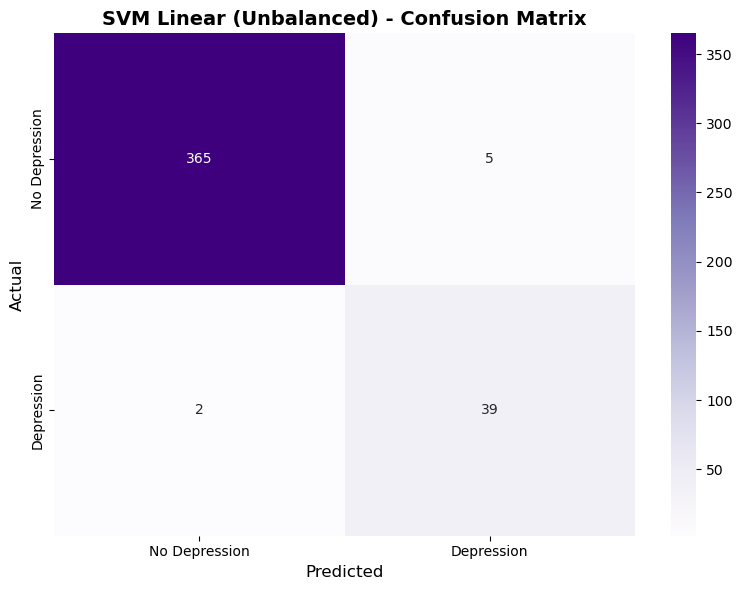

In [166]:
svm_model = SVC(
    kernel='linear',
    random_state=42
)

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Calculate metrics
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='binary')
svm_recall = recall_score(y_test, svm_pred, average='binary')
svm_f1 = f1_score(y_test, svm_pred, average='binary')
svm_cm = confusion_matrix(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_pred)

# Store results
results['SVM'] = {
    'accuracy': svm_accuracy,
    'precision': svm_precision,
    'recall': svm_recall,
    'f1_score': svm_f1,
    'confusion_matrix': svm_cm,
    'predictions': svm_pred,
    'AUC_score': svm_auc
}

print( svm_cm, '\n')
print(classification_report(y_test, svm_pred))
print(f"  Accuracy: {svm_accuracy:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall: {svm_recall:.4f}")
print(f"  F1-Score: {svm_f1:.4f}")
print(f"  AUC: {svm_auc:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Purples', cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('SVM Linear (Unbalanced) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()

In [165]:
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print("-" * 50)
    print(f"Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"Precision: {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
    print(f"Recall:    {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")
    print(f"F1-Score:  {metrics['f1_score']:.4f} ({metrics['f1_score']*100:.2f}%)")
    print(f"AUC:  {metrics['AUC_score']:.4f} ({metrics['AUC_score']*100:.2f}%)")
    print(f"\nConfusion Matrix:")
    print(metrics['confusion_matrix'])
    tn, fp, fn, tp = metrics['confusion_matrix'].ravel()
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")


Random Forest:
--------------------------------------------------
Accuracy:  0.9562 (95.62%)
Precision: 0.9259 (92.59%)
Recall:    0.6098 (60.98%)
F1-Score:  0.7353 (73.53%)
AUC:  0.8022 (80.22%)

Confusion Matrix:
[[368   2]
 [ 16  25]]
  True Negatives:  368
  False Positives: 2
  False Negatives: 16
  True Positives:  25

Logistic Regression:
--------------------------------------------------
Accuracy:  0.9805 (98.05%)
Precision: 0.8837 (88.37%)
Recall:    0.9268 (92.68%)
F1-Score:  0.9048 (90.48%)
AUC:  0.9743 (97.43%)

Confusion Matrix:
[[365   5]
 [  3  38]]
  True Negatives:  365
  False Positives: 5
  False Negatives: 3
  True Positives:  38

SVM:
--------------------------------------------------
Accuracy:  0.9830 (98.30%)
Precision: 0.8864 (88.64%)
Recall:    0.9512 (95.12%)
F1-Score:  0.9176 (91.76%)
AUC:  0.9689 (96.89%)

Confusion Matrix:
[[365   5]
 [  2  39]]
  True Negatives:  365
  False Positives: 5
  False Negatives: 2
  True Positives:  39

Logistic Regression- Bal

In [146]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'AUC_score': [results[m]['AUC_score'] for m in results.keys()]
    
})

print("\n" + comparison_df.to_string(index=False))

# Find best model for each metric
print("\nBest Models:")
print(f"  Highest Accuracy:  {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']} ({comparison_df['Accuracy'].max():.4f})")
print(f"  Highest Precision: {comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']} ({comparison_df['Precision'].max():.4f})")
print(f"  Highest Recall:    {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")
print(f"  Highest F1-Score:  {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"  Highest AUC-Score:  {comparison_df.loc[comparison_df['AUC_score'].idxmax(), 'Model']} ({comparison_df['AUC_score'].max():.4f})")


                        Model  Accuracy  Precision   Recall  F1-Score  AUC_score
                Random Forest  0.956204   0.925926 0.609756  0.735294   0.802175
          Logistic Regression  0.980535   0.883721 0.926829  0.904762   0.974324
                          SVM  0.982968   0.886364 0.951220  0.917647   0.968853
Logistic Regression- Balanced  0.953771   0.683333 1.000000  0.811881   0.974324
                 SVM-Balanced  0.951338   0.672131 1.000000  0.803922   0.972973

Best Models:
  Highest Accuracy:  SVM (0.9830)
  Highest Precision: Random Forest (0.9259)
  Highest Recall:    Logistic Regression- Balanced (1.0000)
  Highest F1-Score:  SVM (0.9176)
  Highest AUC-Score:  Logistic Regression (0.9743)


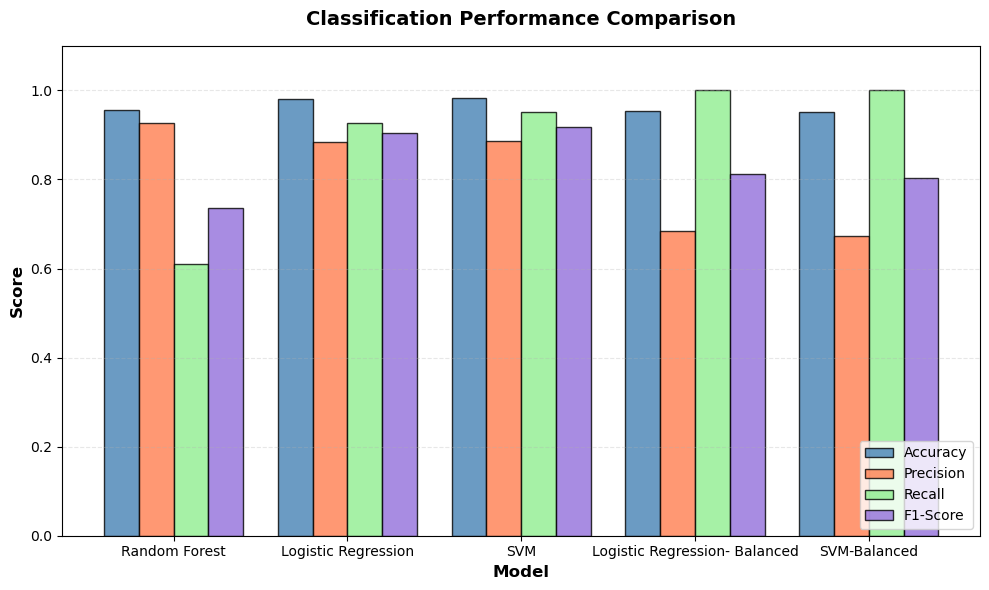

In [167]:
# 7.2 Performance Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(model_names))
width = 0.2

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'mediumpurple']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    values = [results[model][metric.lower().replace('-', '_')] for model in model_names]
    ax.bar(x + i*width, values, width, label=metric, color=color, 
           edgecolor='black', alpha=0.8)

ax.set_xlabel('Model', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Classification Performance Comparison', fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [351]:
# ============================================================================
# SECTION 3: TASK 3 - REGRESSION (Age prediction)
# ============================================================================

In [74]:
X = depression.drop('Age', axis=1)  
y = depression['Age']

In [54]:
X.shape

(2054, 10)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set Age statistics:")
print(f"  Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"  Range: {y_train.min()}-{y_train.max()}")
print(f"\nTest set Age statistics:")
print(f"  Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")
print(f"  Range: {y_test.min()}-{y_test.max()}")

Training set: 1643 samples
Test set: 411 samples

Training set Age statistics:
  Mean: 42.35, Std: 11.27
  Range: 18-60

Test set Age statistics:
  Mean: 41.47, Std: 12.19
  Range: 18-60


In [65]:
min_max_scaler = preprocessing.MinMaxScaler()
X_train=min_max_scaler.fit_transform(X_train)
X_test=min_max_scaler.transform(X_test)

In [76]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_test_pred = lr_model.predict(X_test)
lr_test_r2 = r2_score(y_test, lr_test_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)
lr_test_rmse = np.sqrt(lr_test_mse)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)
print(f"  R² Score: {lr_test_r2:.4f}")
print(f"  Mean Squared Error (MSE): {lr_test_mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {lr_test_rmse:.4f}")
print(f"  Mean Absolute Error (MAE): {lr_test_mae:.4f}")

  R² Score: 0.1914
  Mean Squared Error (MSE): 119.9365
  Root Mean Squared Error (RMSE): 10.9516
  Mean Absolute Error (MAE): 9.1025


In [81]:
print(f"  Average prediction error: ±{lr_test_mae:.2f} years")
print(f"  Model explains {lr_test_r2*100:.2f}% of age variance")

  Average prediction error: ±9.10 years
  Model explains 19.14% of age variance


In [70]:
from sklearn.ensemble import RandomForestRegressor

In [80]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
rf_model.fit(X_train, y_train)
rf_test_pred = rf_model.predict(X_test)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
print(f"  R² Score: {rf_test_r2:.4f}")
print(f"  Mean Squared Error (MSE): {rf_test_mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rf_test_rmse:.4f}")
print(f"  Mean Absolute Error (MAE): {rf_test_mae:.4f}")

  R² Score: 0.1333
  Mean Squared Error (MSE): 128.5585
  Root Mean Squared Error (RMSE): 11.3384
  Mean Absolute Error (MAE): 9.2711


In [94]:
print(f"  Average prediction error: ±{rf_test_mae:.2f} years")
print(f"  Model explains {rf_test_r2*100:.2f}% of age variance")

  Average prediction error: ±9.27 years
  Model explains 13.33% of age variance


In [82]:
comparison = pd.DataFrame({
    'Algorithm': ['Linear Regression', 'Random Forest'],
    'Test_MSE': [lr_test_mse, rf_test_mse],
    'Test_RMSE': [lr_test_rmse, rf_test_rmse],
    'Test_MAE': [lr_test_mae, rf_test_mae],
    'Test_R2': [lr_test_r2, rf_test_r2]
})

print("\nPerformance Comparison Table:")
print(comparison.to_string(index=False))


Performance Comparison Table:
        Algorithm   Test_MSE  Test_RMSE  Test_MAE  Test_R2
Linear Regression 119.936504  10.951553  9.102478 0.191432
    Random Forest 128.558527  11.338365  9.271081 0.133305


In [83]:
best_rmse = comparison.loc[comparison['Test_RMSE'].idxmin(), 'Algorithm']
best_mae = comparison.loc[comparison['Test_MAE'].idxmin(), 'Algorithm']
best_r2 = comparison.loc[comparison['Test_R2'].idxmax(), 'Algorithm']

In [84]:
print(f"\nBest Algorithm by RMSE: {best_rmse} ({comparison['Test_RMSE'].min():.4f})")
print(f"Best Algorithm by MAE: {best_mae} ({comparison['Test_MAE'].min():.4f})")
print(f"Best Algorithm by R²: {best_r2} ({comparison['Test_R2'].max():.4f})")


Best Algorithm by RMSE: Linear Regression (10.9516)
Best Algorithm by MAE: Linear Regression (9.1025)
Best Algorithm by R²: Linear Regression (0.1914)


In [86]:
# Calculate improvement
if best_rmse == 'Random Forest':
    improvement = ((lr_test_rmse - rf_test_rmse) / lr_test_rmse) * 100
    print(f"\nRandom Forest improves RMSE by {improvement:.2f}% over Linear Regression")
else:
    improvement = ((rf_test_rmse - lr_test_rmse) / rf_test_rmse) * 100
    print(f"\nLinear Regression improves RMSE by {improvement:.2f}% over Random Forest")


Linear Regression improves RMSE by 3.41% over Random Forest


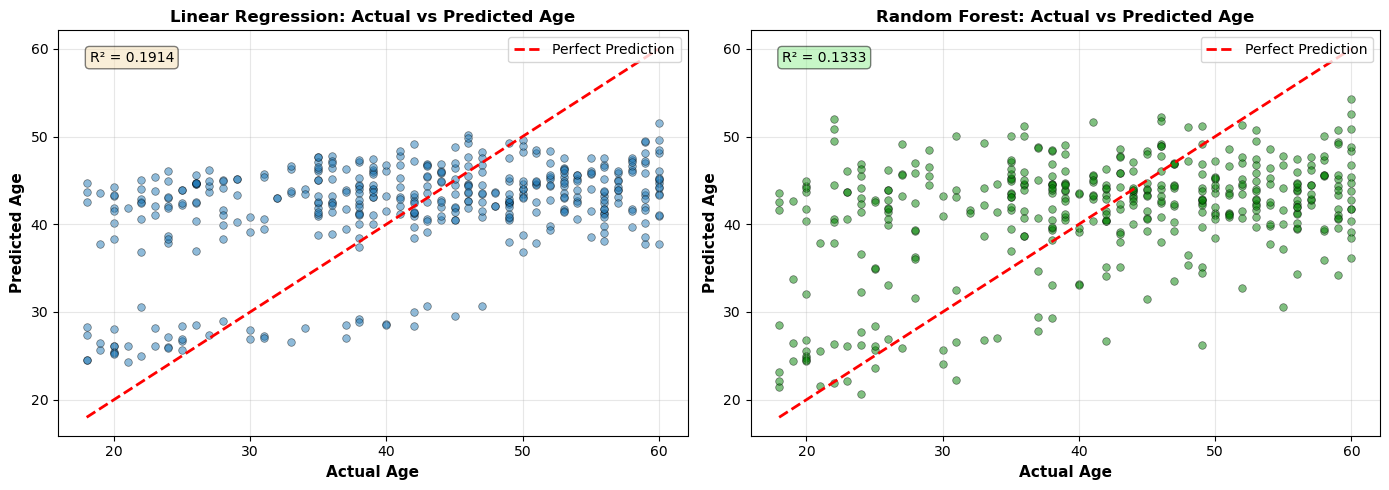

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, lr_test_pred, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Age', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Age', fontsize=11, fontweight='bold')
axes[0].set_title('Linear Regression: Actual vs Predicted Age', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Add R² annotation
lr_r2 = r2_score(y_test, lr_test_pred)
axes[0].text(0.05, 0.95, f'R² = {lr_r2:.4f}', transform=axes[0].transAxes,
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Random Forest
axes[1].scatter(y_test, rf_test_pred, alpha=0.5, s=30, color='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Age', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Age', fontsize=11, fontweight='bold')
axes[1].set_title('Random Forest: Actual vs Predicted Age', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# Add R² annotation
rf_r2 = r2_score(y_test, rf_test_pred)
axes[1].text(0.05, 0.95, f'R² = {rf_r2:.4f}', transform=axes[1].transAxes,
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

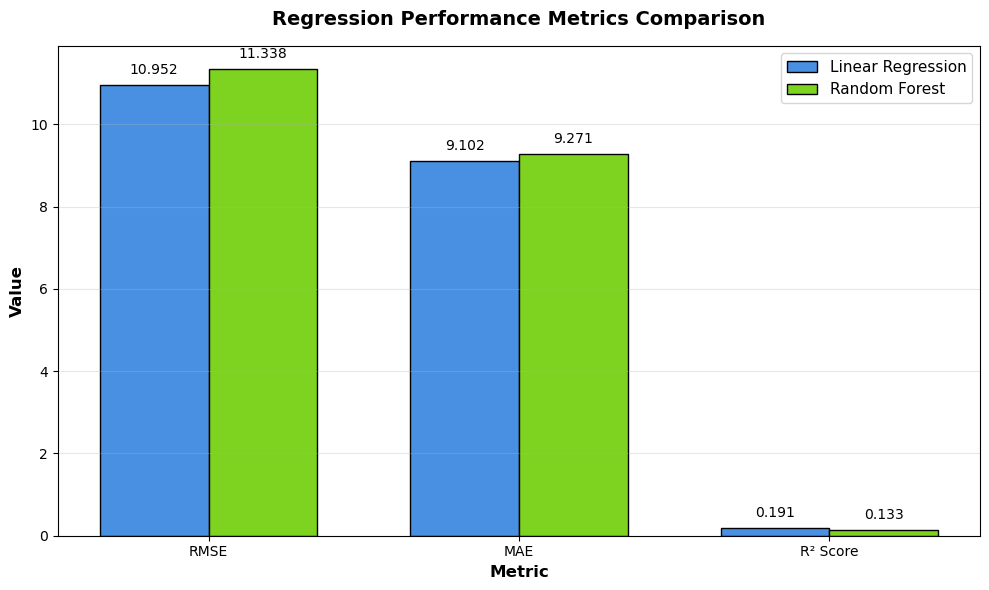

In [90]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['RMSE', 'MAE', 'R² Score']
lr_metrics = [
    np.sqrt(mean_squared_error(y_test, lr_test_pred)),
    mean_absolute_error(y_test, lr_test_pred),
    r2_score(y_test, lr_test_pred)
]
rf_metrics = [
    np.sqrt(mean_squared_error(y_test, rf_test_pred)),
    mean_absolute_error(y_test, rf_test_pred),
    r2_score(y_test, rf_test_pred)
]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, lr_metrics, width, label='Linear Regression', 
               color='#4A90E2', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_metrics, width, label='Random Forest', 
               color='#7ED321', edgecolor='black')

ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_title('Regression Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [349]:
# ============================================================================
# SECTION 4: TASK 4 - Association Rule Mining
# ============================================================================

In [97]:
pip install apyori

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'apyori' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'apyori'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5955 sha256=5c0f9301deea3830107c813ed398764f57f201a2e29065dc78043a71f6defc52
  Stored in directory: /Users/macbook/Library/Caches/pip/wheels/4d/9f/d0/7ba4ae3f5de2f76ea362170ea0f157e6cc1d1b9aea188175f2
Successfully built apyori
Note: you may need to restart the kernel to use updated packages.


In [4]:
from apyori import apriori
pd.set_option('display.max_colwidth', None)

In [93]:
depression.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,37,2,4,1,1,0,6,2,0,0
1,1,60,4,3,0,2,1,0,4,1,0
2,0,42,2,3,0,1,0,0,2,0,0
3,0,44,3,5,1,0,1,1,2,1,0
4,1,48,4,3,1,1,1,6,5,1,0


In [5]:
df_arm= pd.read_csv('Depression_Professional_Dataset.csv')

In [6]:
df_arm.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No


In [7]:
print("Original Work Hours range:")
print(f"Min: {df_arm['Work Hours'].min()}")
print(f"Max: {df_arm['Work Hours'].max()}")
print(f"Contains zeros: {(df_arm['Work Hours'] == 0).sum()}")

Original Work Hours range:
Min: 0
Max: 12
Contains zeros: 170


In [8]:
df_arm['Work Hours'] = pd.cut(df_arm['Work Hours'], 
                               bins=[0, 6, 8, 10, 100], 
                               labels=['Short Hours (0-6)', 'Normal Hours (7-8)', 
                                       'Long Hours (9-10)', 'Very Long Hours (11+)'],
                               include_lowest=True)
print(df_arm['Work Hours'].value_counts())

Work Hours
Short Hours (0-6)        1123
Long Hours (9-10)         342
Very Long Hours (11+)     309
Normal Hours (7-8)        280
Name: count, dtype: int64


In [9]:
df_arm['Age'] = pd.cut(df_arm['Age'], 
                                 bins=[0, 30, 40, 50, 100], 
                                 labels=['Young (18-30)', 'Early Middle (31-40)', 
                                         'Late Middle (41-50)', 'Senior (51+)'])
print(df_arm['Age'].value_counts())

Age
Late Middle (41-50)     611
Senior (51+)            577
Early Middle (31-40)    479
Young (18-30)           387
Name: count, dtype: int64


In [10]:
df_arm['Work Pressure'] = pd.cut(df_arm['Work Pressure'], 
                                        bins=[0, 2, 3, 4, 5], 
                                        labels=['Low Pressure (1-2)', 'Moderate Pressure (3)', 
                                                'High Pressure (4)', 'Very High Pressure (5)'])
print(df_arm['Work Pressure'].value_counts())

Work Pressure
Low Pressure (1-2)        814
Very High Pressure (5)    424
High Pressure (4)         412
Moderate Pressure (3)     404
Name: count, dtype: int64


In [11]:
df_arm['Job Satisfaction'] = pd.cut(df_arm['Job Satisfaction'], 
                                           bins=[0, 2, 3, 4, 5], 
                                           labels=['Very Dissatisfied (1-2)', 'Neutral (3)', 
                                                   'Satisfied (4)', 'Very Satisfied (5)'])
print(df_arm['Job Satisfaction'].value_counts())

Job Satisfaction
Very Dissatisfied (1-2)    827
Very Satisfied (5)         431
Neutral (3)                404
Satisfied (4)              392
Name: count, dtype: int64


In [12]:
df_arm['Financial Stress'] = pd.cut(df_arm['Financial Stress'], 
                                           bins=[0, 2, 3, 4, 5], 
                                           labels=['Low Stress (1-2)', 'Moderate Stress (3)', 
                                                   'High Stress (4)', 'Very High Stress (5)'])
print(df_arm['Financial Stress'].value_counts())

Financial Stress
Low Stress (1-2)        854
High Stress (4)         407
Very High Stress (5)    405
Moderate Stress (3)     388
Name: count, dtype: int64


In [13]:
df_arm.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,Early Middle (31-40),Low Pressure (1-2),Satisfied (4),7-8 hours,Moderate,No,Short Hours (0-6),Low Stress (1-2),No,No
1,Male,Senior (51+),High Pressure (4),Neutral (3),5-6 hours,Unhealthy,Yes,Short Hours (0-6),High Stress (4),Yes,No
2,Female,Late Middle (41-50),Low Pressure (1-2),Neutral (3),5-6 hours,Moderate,No,Short Hours (0-6),Low Stress (1-2),No,No
3,Female,Late Middle (41-50),Moderate Pressure (3),Very Satisfied (5),7-8 hours,Healthy,Yes,Short Hours (0-6),Low Stress (1-2),Yes,No
4,Male,Late Middle (41-50),High Pressure (4),Neutral (3),7-8 hours,Moderate,Yes,Short Hours (0-6),Very High Stress (5),Yes,No


In [14]:
df_arm.shape

(2054, 11)

In [15]:
transactions = []
for i in range(len(df_arm)):
    transaction = []
    
    # Add each attribute as "Attribute=Value" format
    transaction.append(f"Gender={df_arm.iloc[i]['Gender']}")
    transaction.append(f"Age={df_arm.iloc[i]['Age']}")
    transaction.append(f"WorkPressure={df_arm.iloc[i]['Work Pressure']}")
    transaction.append(f"JobSatisfaction={df_arm.iloc[i]['Job Satisfaction']}")
    transaction.append(f"Sleep={df_arm.iloc[i]['Sleep Duration']}")
    transaction.append(f"Diet={df_arm.iloc[i]['Dietary Habits']}")
    transaction.append(f"WorkHours={df_arm.iloc[i]['Work Hours']}")
    transaction.append(f"FinancialStress={df_arm.iloc[i]['Financial Stress']}")
    transaction.append(f"SuicidalThoughts={df_arm.iloc[i]['Have you ever had suicidal thoughts ?']}")
    transaction.append(f"FamilyHistory={df_arm.iloc[i]['Family History of Mental Illness']}")
    transaction.append(f"Depression={df_arm.iloc[i]['Depression']}")
    
    transactions.append(transaction)

print(f"\nTotal transactions: {len(transactions)}")


Total transactions: 2054


In [16]:
# Parameters
min_support = 0.03  
min_confidence = 0.4  

# Run Apriori
rules = apriori(transactions, 
                min_support=min_support,
                min_confidence=min_confidence,
                max_length=4)  # Maximum 4 items in a rule (to keep it interpretable)

# Convert to list
rules_list = list(rules)

print(f"\nNumber of rules generated: {len(rules_list)}")


Number of rules generated: 4013


In [17]:
#Put the results into a dataframe to have the rules listed in a table
df = pd.DataFrame(columns=('Items','Antecedent','Consequent','Support','Confidence','Lift'))

Support =[]
Confidence = []
Lift = []
Items = []
Antecedent = []
Consequent=[]

for RelationRecord in rules_list:
    for ordered_stat in RelationRecord.ordered_statistics:
        Support.append(RelationRecord.support)
        Items.append(RelationRecord.items)
        Antecedent.append(ordered_stat.items_base)
        Consequent.append(ordered_stat.items_add)
        Confidence.append(ordered_stat.confidence)
        Lift.append(ordered_stat.lift)

df['Items'] = list(map(set, Items))
df['Antecedent'] = list(map(set, Antecedent))
df['Consequent'] = list(map(set, Consequent))
df['Support'] = Support
df['Confidence'] = Confidence
df['Lift']= Lift

#Sort resulted dataframe by Lift
df.sort_values(by ='Lift', ascending = False, inplace = True)

In [18]:
df.reset_index(drop=True, inplace=True)
df.shape

(10173, 6)

In [19]:
df.head()

,Items,Antecedent,Consequent,Support,Confidence,Lift
0,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}","{SuicidalThoughts=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",{Depression=Yes},0.031159,0.810127,8.197044
1,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30)}",{Depression=Yes},"{SuicidalThoughts=Yes, Age=Young (18-30)}",0.053554,0.541872,5.766865
2,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30)}","{SuicidalThoughts=Yes, Age=Young (18-30)}",{Depression=Yes},0.053554,0.569948,5.766865
3,"{Depression=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}","{Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",{Depression=Yes},0.040896,0.556291,5.628682
4,"{Depression=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",{Depression=Yes},"{Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",0.040896,0.413793,5.628682


In [20]:
above_1 = df[df["Lift"] > 1]

In [21]:
above_1.shape

(6668, 6)

In [22]:
pd.set_option('display.max_rows', 1000) 
above_1.head(500)

,Items,Antecedent,Consequent,Support,Confidence,Lift
0,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}","{SuicidalThoughts=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",{Depression=Yes},0.031159,0.810127,8.197044
1,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30)}",{Depression=Yes},"{SuicidalThoughts=Yes, Age=Young (18-30)}",0.053554,0.541872,5.766865
2,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30)}","{SuicidalThoughts=Yes, Age=Young (18-30)}",{Depression=Yes},0.053554,0.569948,5.766865
3,"{Depression=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}","{Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",{Depression=Yes},0.040896,0.556291,5.628682
4,"{Depression=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",{Depression=Yes},"{Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}",0.040896,0.413793,5.628682
5,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}","{Depression=Yes, JobSatisfaction=Very Dissatisfied (1-2)}","{SuicidalThoughts=Yes, Age=Young (18-30)}",0.031159,0.488550,5.199383
6,"{Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}","{Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}","{Depression=Yes, SuicidalThoughts=Yes}",0.031159,0.423841,5.091050
7,"{Depression=Yes, FamilyHistory=No, Age=Young (18-30)}","{Depression=Yes, FamilyHistory=No}",{Age=Young (18-30)},0.036514,0.765306,4.061857
8,"{Depression=Yes, Gender=Female, Age=Young (18-30)}","{Depression=Yes, Gender=Female}",{Age=Young (18-30)},0.034567,0.710000,3.768320
9,"{Depression=Yes, Age=Young (18-30)}",{Depression=Yes},{Age=Young (18-30)},0.068647,0.694581,3.686486


In [23]:
print(above_1.loc[[2]])

                                                       Items  \
2  {Depression=Yes, SuicidalThoughts=Yes, Age=Young (18-30)}   

                                  Antecedent        Consequent   Support  \
2  {SuicidalThoughts=Yes, Age=Young (18-30)}  {Depression=Yes}  0.053554   

   Confidence      Lift  
2    0.569948  5.766865  


In [24]:
print(above_1.loc[[3]])

                                                                          Items  \
3  {Depression=Yes, Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}   

                                                     Antecedent  \
3  {Age=Young (18-30), JobSatisfaction=Very Dissatisfied (1-2)}   

         Consequent   Support  Confidence      Lift  
3  {Depression=Yes}  0.040896    0.556291  5.628682  


In [25]:
print(above_1.loc[[7]])

                                                   Items  \
7  {Depression=Yes, FamilyHistory=No, Age=Young (18-30)}   

                           Antecedent           Consequent   Support  \
7  {Depression=Yes, FamilyHistory=No}  {Age=Young (18-30)}  0.036514   

   Confidence      Lift  
7    0.765306  4.061857  


In [26]:
print(above_1.loc[[8]])

                                                Items  \
8  {Depression=Yes, Gender=Female, Age=Young (18-30)}   

                        Antecedent           Consequent   Support  Confidence  \
8  {Depression=Yes, Gender=Female}  {Age=Young (18-30)}  0.034567        0.71   

      Lift  
8  3.76832  


In [27]:
print(above_1.loc[[38]])

                                                                          Items  \
38  {Depression=Yes, SuicidalThoughts=Yes, WorkPressure=Very High Pressure (5)}   

                                               Antecedent  \
38  {Depression=Yes, WorkPressure=Very High Pressure (5)}   

                Consequent   Support  Confidence      Lift  
38  {SuicidalThoughts=Yes}  0.032132    0.785714  1.631807  


In [28]:
print(above_1.loc[[52]])

                                                                      Items  \
52  {Depression=No, Age=Senior (51+), SuicidalThoughts=Yes, Diet=Unhealthy}   

                            Antecedent                             Consequent  \
52  {Age=Senior (51+), Diet=Unhealthy}  {Depression=No, SuicidalThoughts=Yes}   

     Support  Confidence      Lift  
52  0.051607     0.56383  1.415778  


In [29]:
print(above_1.loc[[85]])

                                                                                      Items  \
85  {Depression=No, WorkPressure=Low Pressure (1-2), Diet=Healthy, Sleep=More than 8 hours}   

                                                    Antecedent  \
85  {Sleep=More than 8 hours, WorkPressure=Low Pressure (1-2)}   

                       Consequent   Support  Confidence     Lift  
85  {Depression=No, Diet=Healthy}  0.041383    0.400943  1.29691  


In [30]:
print(above_1.loc[[102]])


                                                                                    Items  \
102  {Depression=No, Gender=Female, Age=Late Middle (41-50), JobSatisfaction=Neutral (3)}   

                                                 Antecedent  \
102  {JobSatisfaction=Neutral (3), Age=Late Middle (41-50)}   

                         Consequent   Support  Confidence      Lift  
102  {Depression=No, Gender=Female}  0.032619     0.54918  1.270289  


In [34]:
print(above_1.loc[[194]])


                                                                                                                  Items  \
194  {Depression=No, WorkPressure=Very High Pressure (5), SuicidalThoughts=No, JobSatisfaction=Very Dissatisfied (1-2)}   

                                                                                        Antecedent  \
194  {Depression=No, WorkPressure=Very High Pressure (5), JobSatisfaction=Very Dissatisfied (1-2)}   

                Consequent   Support  Confidence      Lift  
194  {SuicidalThoughts=No}  0.039435    0.632812  1.220467  


In [348]:
# ============================================================================
# SECTION 5: TASK 5 - Clustering
# ============================================================================

In [265]:
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

In [266]:
depression.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,37,2,4,1,1,0,6,2,0,0
1,1,60,4,3,0,2,1,0,4,1,0
2,0,42,2,3,0,1,0,0,2,0,0
3,0,44,3,5,1,0,1,1,2,1,0
4,1,48,4,3,1,1,1,6,5,1,0


In [267]:
#standardise the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(depression.values)
scaled_features_depression = pd.DataFrame(scaled_features, index=depression.index, columns=depression.columns)
scaled_features_depression.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
count,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03
mean,2.248553e-17,-1.055090e-16,1.176166e-16,-8.475315e-17,-2.075587e-17,-7.956418e-17,-6.659176e-17,-4.151175e-17,1.245352e-16,2.248553e-17,8.648281e-18
std,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00
min,-1.038724e+00,-2.109530e+00,-1.426927e+00,-1.420994e+00,-1.348198e+00,-1.232992e+00,-9.636589e-01,-1.571912e+00,-1.400250e+00,-9.816675e-01,-3.311653e-01
25%,-1.038724e+00,-6.259035e-01,-7.211941e-01,-7.158184e-01,-4.438221e-01,-1.232992e+00,-9.636589e-01,-7.767947e-01,-6.925449e-01,-9.816675e-01,-3.311653e-01
50%,9.627197e-01,7.227356e-02,-1.546152e-02,-1.064286e-02,-4.438221e-01,-1.891455e-02,-9.636589e-01,1.832306e-02,1.516019e-02,-9.816675e-01,-3.311653e-01
75%,9.627197e-01,8.359047e-01,6.902710e-01,6.945326e-01,4.605535e-01,1.195163e+00,1.037712e+00,8.134408e-01,7.228652e-01,1.018675e+00,-3.311653e-01
max,9.627197e-01,1.555900e+00,1.396004e+00,1.399708e+00,1.364929e+00,1.195163e+00,1.037712e+00,1.608558e+00,1.430570e+00,1.018675e+00,3.019640e+00


In [268]:
#######################################
###             k-means             ###
#######################################

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(scaled_features_depression)

KMeans(n_clusters=3, random_state=0)

In [269]:
kmeans.cluster_centers_

array([[ 2.10918368e-02,  3.11297784e-02, -5.89689815e-03,
         4.12383938e-02,  9.67892110e-03, -5.29980511e-02,
        -9.63658911e-01, -1.60576318e-02, -2.38903345e-02,
        -5.70184428e-03, -3.31165289e-01],
       [-2.08748261e-02,  2.76370856e-01, -1.40560812e-01,
         7.29781930e-02, -1.26405844e-02, -5.55672753e-03,
         1.03771157e+00, -7.59635120e-02, -8.34686348e-02,
        -5.95040930e-03, -3.31165289e-01],
       [-2.32131020e-02, -1.27206119e+00,  5.96405122e-01,
        -5.03918338e-01,  1.68311608e-03,  2.92080738e-01,
         7.22224596e-01,  3.87811264e-01,  4.57911620e-01,
         5.29923150e-02,  3.01964014e+00]])

In [270]:
# Compute the silhouette score
kmeans_silhouette = silhouette_score(scaled_features_depression, kmeans.labels_).round(2)
kmeans_silhouette

np.float64(0.12)

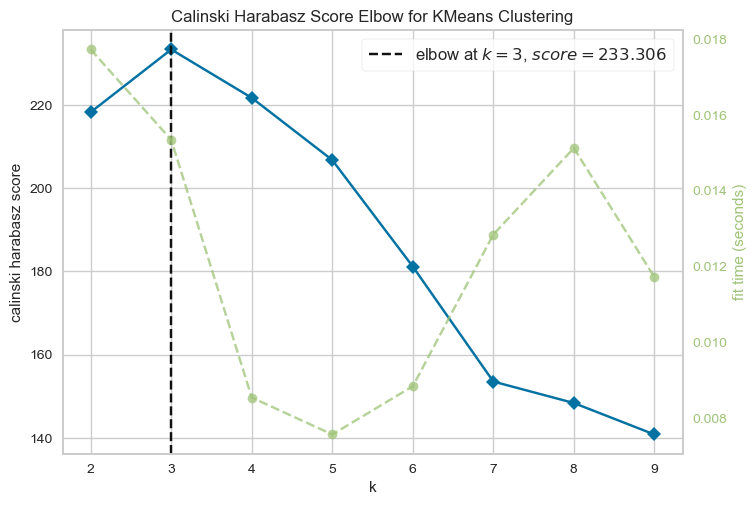

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [272]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,10), metric='calinski_harabasz')

visualizer.fit(scaled_features_depression)        # Fit the data to the visualizer
visualizer.show()                            # Finalize and render the figure

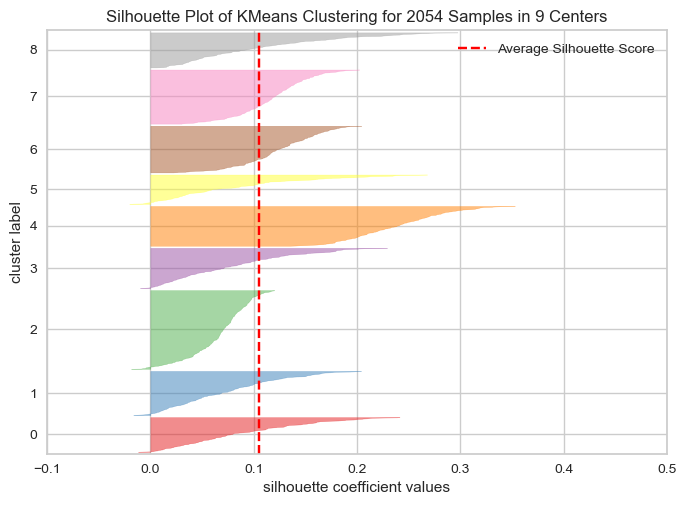

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2054 Samples in 9 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [273]:
#SilhouetteVisualizer
visualizer = SilhouetteVisualizer(model)

visualizer.fit(scaled_features_depression)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [274]:
# Calculate metrics
kmeans_silhouette = silhouette_score(scaled_features_depression, kmeans.labels_)
kmeans_dbi = davies_bouldin_score(scaled_features_depression, kmeans.labels_)
kmeans_chi = calinski_harabasz_score(scaled_features_depression, kmeans.labels_)

print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {kmeans_dbi:.4f} (lower is better)")
print(f"  Calinski-Harabasz Score: {kmeans_chi:.4f} (higher is better)")

  Silhouette Score: 0.1226
  Davies-Bouldin Index: 2.4287 (lower is better)
  Calinski-Harabasz Score: 265.3491 (higher is better)


In [275]:
# Cluster sizes
unique, counts = np.unique(kmeans.labels_, return_counts=True)
print(f"\nCluster Sizes:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(kmeans.labels_)*100:.1f}%)")


Cluster Sizes:
  Cluster 0: 1033 samples (50.3%)
  Cluster 1: 818 samples (39.8%)
  Cluster 2: 203 samples (9.9%)


In [276]:
scaled_features_depression.head(10)

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,-1.038724,-0.451359,-0.721194,0.694533,-0.443822,-0.018915,-0.963659,0.018323,-0.692545,-0.981668,-0.331165
1,0.962720,1.555900,0.690271,-0.010643,-1.348198,1.195163,1.037712,-1.571912,0.722865,1.018675,-0.331165
2,-1.038724,-0.014999,-0.721194,-0.010643,-1.348198,-0.018915,-0.963659,-1.571912,-0.692545,-0.981668,-0.331165
3,-1.038724,0.159546,-0.015462,1.399708,-0.443822,-1.232992,1.037712,-1.306873,-0.692545,1.018675,-0.331165
4,0.962720,0.508634,0.690271,-0.010643,-0.443822,-0.018915,1.037712,0.018323,1.430570,1.018675,-0.331165
5,-1.038724,1.555900,-1.426927,0.694533,-0.443822,1.195163,1.037712,1.608558,0.015160,1.018675,-0.331165
6,-1.038724,-1.062264,0.690271,-0.715818,1.364929,-1.232992,-0.963659,-0.776795,-1.400250,-0.981668,-0.331165
7,0.962720,-1.062264,-1.426927,-0.715818,1.364929,1.195163,1.037712,0.018323,-1.400250,-0.981668,-0.331165
8,0.962720,1.206811,-1.426927,-0.715818,1.364929,-0.018915,1.037712,1.343519,1.430570,1.018675,-0.331165
9,-1.038724,-0.625903,-0.015462,0.694533,0.460553,-0.018915,-0.963659,0.018323,0.722865,1.018675,-0.331165


In [277]:
scaled_features_depression.shape

(2054, 11)

In [278]:
scaled_features_depression['cluster'] = kmeans.labels_

In [279]:
cluster1 = scaled_features_depression.query("cluster == 0")
cluster2 = scaled_features_depression.query("cluster == 1")
cluster3 = scaled_features_depression.query("cluster == 2")

In [280]:
cluster1.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster
0,-1.038724,-0.451359,-0.721194,0.694533,-0.443822,-0.018915,-0.963659,0.018323,-0.692545,-0.981668,-0.331165,0
2,-1.038724,-0.014999,-0.721194,-0.010643,-1.348198,-0.018915,-0.963659,-1.571912,-0.692545,-0.981668,-0.331165,0
6,-1.038724,-1.062264,0.690271,-0.715818,1.364929,-1.232992,-0.963659,-0.776795,-1.400250,-0.981668,-0.331165,0
9,-1.038724,-0.625903,-0.015462,0.694533,0.460553,-0.018915,-0.963659,0.018323,0.722865,1.018675,-0.331165,0
10,0.962720,-1.847713,-0.721194,1.399708,0.460553,-0.018915,-0.963659,0.018323,-1.400250,1.018675,-0.331165,0


In [281]:
cluster1.shape

(1033, 12)

In [282]:
cluster1.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster
count,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000,1.033000e+03,1033.000000,1033.000000,1033.000000,1.033000e+03,1033.0
mean,0.021092,0.031130,-0.005897,0.041238,0.009679,-0.052998,-9.636589e-01,-0.016058,-0.023890,-0.005702,-3.311653e-01,0.0
std,0.999459,0.940253,0.985847,1.001225,1.015131,1.011392,1.177406e-14,0.981774,0.989104,1.000363,1.610603e-15,0.0
min,-1.038724,-2.109530,-1.426927,-1.420994,-1.348198,-1.232992,-9.636589e-01,-1.571912,-1.400250,-0.981668,-3.311653e-01,0.0
25%,-1.038724,-0.625903,-0.721194,-0.715818,-0.443822,-1.232992,-9.636589e-01,-0.776795,-0.692545,-0.981668,-3.311653e-01,0.0
50%,0.962720,0.072274,-0.015462,-0.010643,-0.443822,-0.018915,-9.636589e-01,0.018323,0.015160,-0.981668,-3.311653e-01,0.0
75%,0.962720,0.770451,0.690271,0.694533,1.364929,1.195163,-9.636589e-01,0.813441,0.722865,1.018675,-3.311653e-01,0.0
max,0.962720,1.555900,1.396004,1.399708,1.364929,1.195163,-9.636589e-01,1.608558,1.430570,1.018675,-3.311653e-01,0.0


In [283]:
cluster2.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster
1,0.962720,1.555900,0.690271,-0.010643,-1.348198,1.195163,1.037712,-1.571912,0.722865,1.018675,-0.331165,1
3,-1.038724,0.159546,-0.015462,1.399708,-0.443822,-1.232992,1.037712,-1.306873,-0.692545,1.018675,-0.331165,1
4,0.962720,0.508634,0.690271,-0.010643,-0.443822,-0.018915,1.037712,0.018323,1.430570,1.018675,-0.331165,1
5,-1.038724,1.555900,-1.426927,0.694533,-0.443822,1.195163,1.037712,1.608558,0.015160,1.018675,-0.331165,1
7,0.962720,-1.062264,-1.426927,-0.715818,1.364929,1.195163,1.037712,0.018323,-1.400250,-0.981668,-0.331165,1


In [284]:
cluster2.shape

(818, 12)

In [285]:
cluster2.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster
count,818.000000,818.000000,818.000000,818.000000,818.000000,818.000000,8.180000e+02,818.000000,818.000000,818.000000,8.180000e+02,818.0
mean,-0.020875,0.276371,-0.140561,0.072978,-0.012641,-0.005557,1.037712e+00,-0.075964,-0.083469,-0.005950,-3.311653e-01,1.0
std,1.001187,0.881137,0.994782,0.976764,1.001577,0.980525,1.577481e-14,1.010303,0.994737,1.000484,2.888346e-15,0.0
min,-1.038724,-2.109530,-1.426927,-1.420994,-1.348198,-1.232992,1.037712e+00,-1.571912,-1.400250,-0.981668,-3.311653e-01,1.0
25%,-1.038724,-0.364087,-0.721194,-0.715818,-0.443822,-1.232992,1.037712e+00,-1.041834,-0.692545,-0.981668,-3.311653e-01,1.0
50%,0.962720,0.421362,-0.015462,-0.010643,-0.443822,-0.018915,1.037712e+00,-0.246716,0.015160,-0.981668,-3.311653e-01,1.0
75%,0.962720,1.032267,0.690271,0.694533,0.460553,1.195163,1.037712e+00,0.813441,0.722865,1.018675,-3.311653e-01,1.0
max,0.962720,1.555900,1.396004,1.399708,1.364929,1.195163,1.037712e+00,1.608558,1.430570,1.018675,-3.311653e-01,1.0


In [286]:
cluster3.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster
14,0.962720,-2.109530,-0.015462,-1.420994,1.364929,1.195163,1.037712,0.283362,0.015160,-0.981668,3.01964,2
38,-1.038724,-1.760441,0.690271,1.399708,-1.348198,1.195163,1.037712,1.608558,0.015160,1.018675,3.01964,2
55,-1.038724,-1.934985,-0.015462,1.399708,0.460553,-0.018915,1.037712,0.813441,1.430570,-0.981668,3.01964,2
60,-1.038724,-0.625903,1.396004,-0.715818,0.460553,-0.018915,1.037712,-0.511755,0.015160,1.018675,3.01964,2
63,0.962720,-2.022258,-0.721194,0.694533,0.460553,-0.018915,1.037712,1.343519,0.722865,-0.981668,3.01964,2


In [287]:
cluster3.shape

(203, 12)

In [288]:
cluster3.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster
count,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,2.030000e+02,203.0
mean,-0.023213,-1.272061,0.596405,-0.503918,0.001683,0.292081,0.722225,0.387811,0.457912,0.052992,3.019640e+00,2.0
std,1.003086,0.755671,0.873436,0.950078,0.919337,0.976506,0.731100,0.969427,0.962386,1.002048,2.671123e-15,0.0
min,-1.038724,-2.109530,-1.426927,-1.420994,-1.348198,-1.232992,-0.963659,-1.571912,-1.400250,-0.981668,3.019640e+00,2.0
25%,-1.038724,-1.847713,-0.015462,-1.420994,-0.443822,-0.018915,1.037712,-0.511755,0.015160,-0.981668,3.019640e+00,2.0
50%,0.962720,-1.498625,0.690271,-0.715818,0.460553,-0.018915,1.037712,0.548402,0.722865,1.018675,3.019640e+00,2.0
75%,0.962720,-0.800448,1.396004,-0.010643,0.460553,1.195163,1.037712,1.078480,1.430570,1.018675,3.019640e+00,2.0
max,0.962720,0.770451,1.396004,1.399708,1.364929,1.195163,1.037712,1.608558,1.430570,1.018675,3.019640e+00,2.0


In [289]:
cluster1_mean = kmeans.cluster_centers_[0]
cluster2_mean = kmeans.cluster_centers_[1]
cluster3_mean = kmeans.cluster_centers_[2]

In [290]:
cluster1.keys()

Index(['Gender', 'Age', 'Work Pressure', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'cluster'],
      dtype='object')

In [291]:
cluster1_mean_p1 = cluster1_mean[:8]
cluster2_mean_p1 = cluster2_mean[:8]
cluster3_mean_p1 = cluster3_mean[:8]

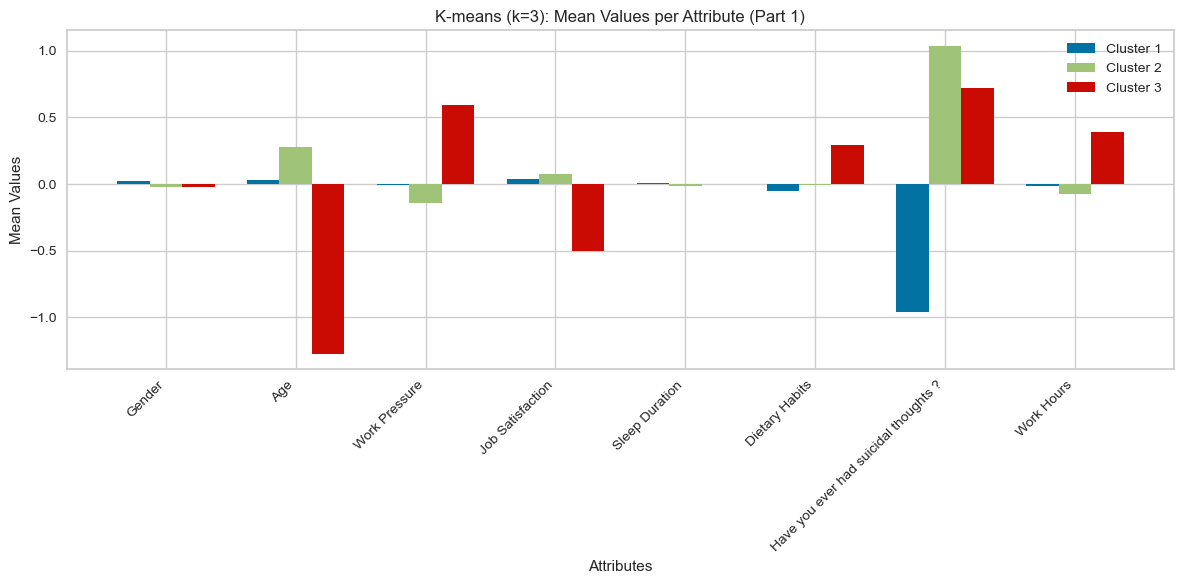

In [292]:
X_labels = list(cluster1.keys()[:8])
X_axis = np.arange(len(X_labels))

plt.figure(figsize=(12, 6))
plt.bar(X_axis - 0.25, cluster1_mean_p1, 0.25, label='Cluster 1')
plt.bar(X_axis, cluster2_mean_p1, 0.25, label='Cluster 2')
plt.bar(X_axis + 0.25, cluster3_mean_p1, 0.25, label='Cluster 3')

plt.xticks(X_axis, X_labels, rotation=45, ha='right')
plt.xlabel("Attributes")
plt.ylabel("Mean Values")
plt.title("K-means (k=3): Mean Values per Attribute (Part 1)")
plt.legend()
plt.tight_layout()
plt.show()

In [293]:
cluster1_mean_p2 = cluster1_mean[8:]
cluster2_mean_p2 = cluster2_mean[8:]
cluster3_mean_p2 = cluster3_mean[8:]

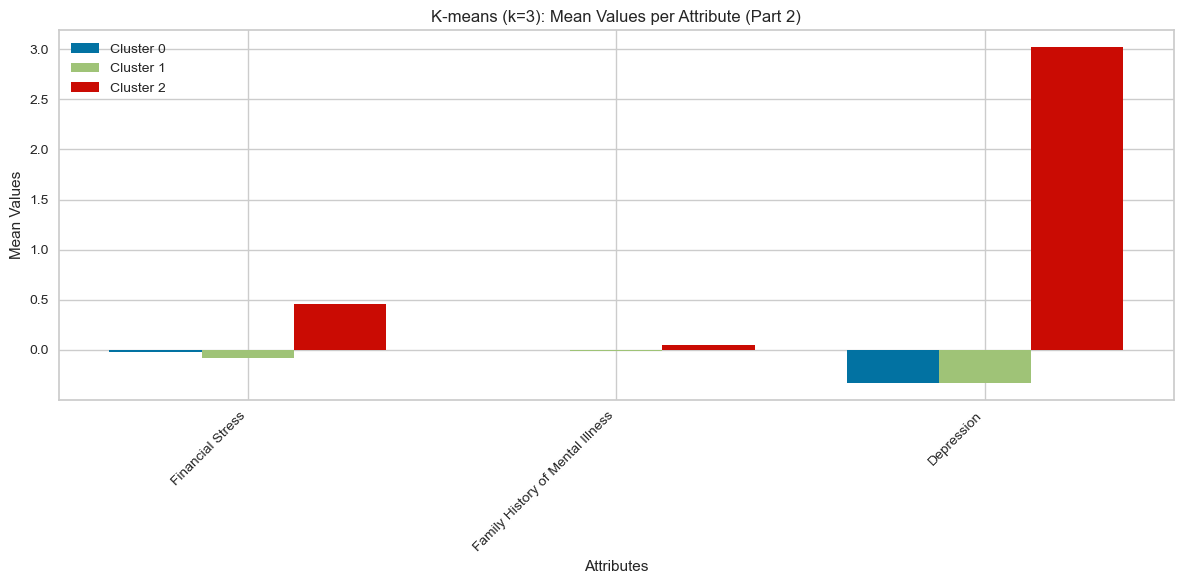

In [294]:
n_remaining = len(cluster1_mean[8:])

cluster1_mean_p2 = cluster1_mean[8:8+n_remaining]
cluster2_mean_p2 = cluster2_mean[8:8+n_remaining]
cluster3_mean_p2 = cluster3_mean[8:8+n_remaining]

X_labels = list(cluster1.keys()[8:8+n_remaining])
X_axis = np.arange(n_remaining)

plt.figure(figsize=(12, 6))
plt.bar(X_axis - 0.25, cluster1_mean_p2, 0.25, label='Cluster 0')
plt.bar(X_axis, cluster2_mean_p2, 0.25, label='Cluster 1')
plt.bar(X_axis + 0.25, cluster3_mean_p2, 0.25, label='Cluster 2')

plt.xticks(X_axis, X_labels, rotation=45, ha='right')
plt.xlabel("Attributes")
plt.ylabel("Mean Values")
plt.title("K-means (k=3): Mean Values per Attribute (Part 2)")
plt.legend()
plt.tight_layout()
plt.show()

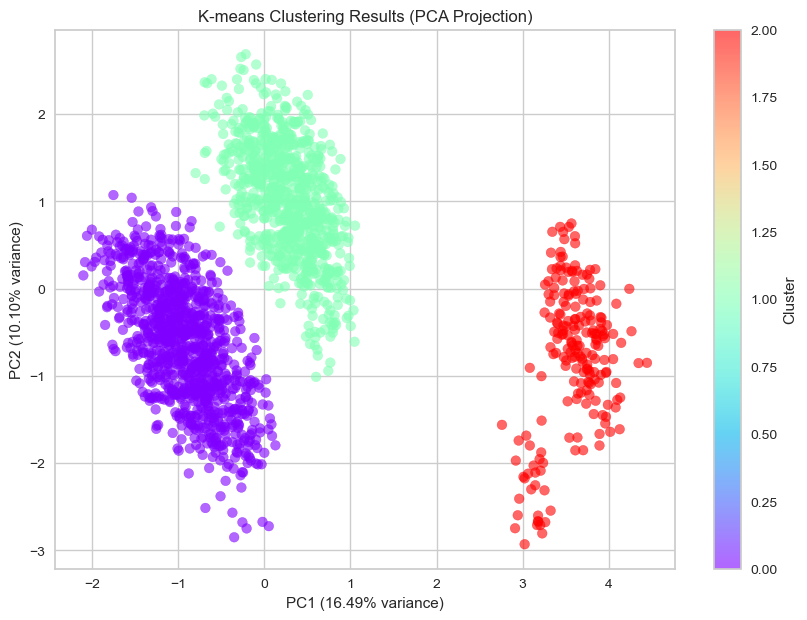


=== K-MEANS CLUSTER COVERAGE ===
Cluster 0: 1033 samples (50.29%)
Cluster 1: 818 samples (39.82%)
Cluster 2: 203 samples (9.88%)


In [295]:
from sklearn.decomposition import PCA

# For K-means visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features_depression)

plt.figure(figsize=(10, 7))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans.labels_, cmap='rainbow', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-means Clustering Results (PCA Projection)')
plt.colorbar(label='Cluster')
plt.show()

# 2. ADD COVERAGE ANALYSIS
print("\n=== K-MEANS CLUSTER COVERAGE ===")
unique, counts = np.unique(kmeans.labels_, return_counts=True)
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(kmeans.labels_)) * 100
    print(f"Cluster {cluster_id}: {count} samples ({percentage:.2f}%)")

In [319]:
######################################################
###             Hierarchical Clustering            ###
######################################################

from sklearn.cluster import AgglomerativeClustering



# setting distance_threshold=0 ensures we compute the full tree.
cluster = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete',compute_distances=True)
cluster.fit(scaled_features_depression)

AgglomerativeClustering(compute_distances=True, linkage='complete',
                        n_clusters=3)

In [328]:
#change the parameters
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hierarchical_labels = cluster.fit_predict(scaled_features_depression)

In [329]:
from sklearn.metrics import silhouette_score
hierarchical_score = silhouette_score(scaled_features_depression, hierarchical_labels)
print(f"\nHierarchical Silhouette Score: {hierarchical_score:.3f}")


Hierarchical Silhouette Score: 0.206


In [330]:
# Calculate metrics
hier_silhouette = silhouette_score(scaled_features_depression, hierarchical_labels)
hier_dbi = davies_bouldin_score(scaled_features_depression, hierarchical_labels)
hier_chi = calinski_harabasz_score(scaled_features_depression, hierarchical_labels)

print(f"  Silhouette Score: {hier_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {hier_dbi:.4f} (lower is better)")
print(f"  Calinski-Harabasz Score: {hier_chi:.4f} (higher is better)")



  Silhouette Score: 0.2060
  Davies-Bouldin Index: 1.7740 (lower is better)
  Calinski-Harabasz Score: 416.2793 (higher is better)


In [331]:
# Cluster sizes
unique, counts = np.unique(hierarchical_labels, return_counts=True)
print(f"\nCluster Sizes:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(hierarchical_labels)*100:.1f}%)")


Cluster Sizes:
  Cluster 0: 814 samples (39.6%)
  Cluster 1: 1037 samples (50.5%)
  Cluster 2: 203 samples (9.9%)


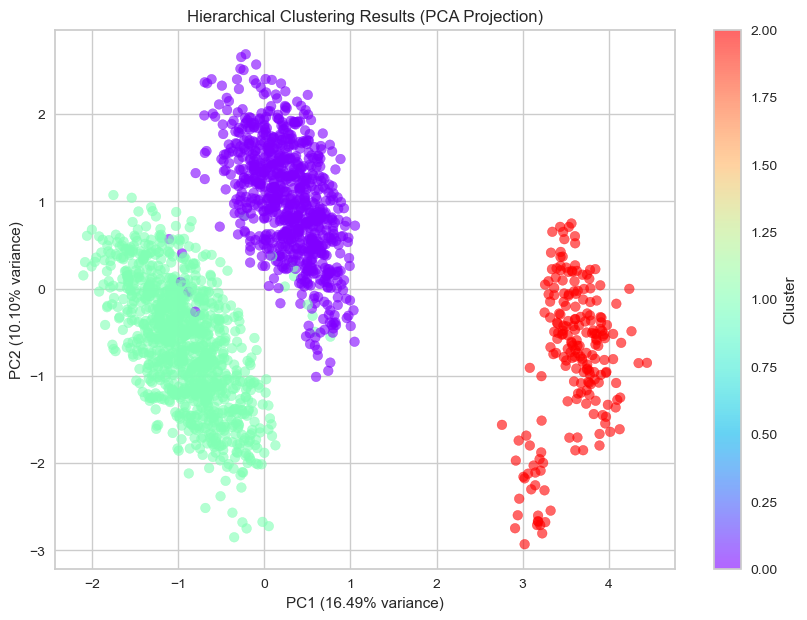


=== HIERARCHICAL CLUSTER COVERAGE ===
Cluster 0: 814 samples (39.63%)
Cluster 1: 1037 samples (50.49%)
Cluster 2: 203 samples (9.88%)


In [334]:
# ========================================
# PCA VISUALIZATION FOR HIERARCHICAL CLUSTERING
# ========================================


if 'cluster_no' in scaled_features_depression.columns:
    X_for_pca = scaled_features_depression.drop(columns=['cluster_no'])  # Use columns parameter
else:
    X_for_pca = scaled_features_depression.copy()



pca_hierarchical = PCA(n_components=2)
pca_features_hierarchical = pca_hierarchical.fit_transform(X_for_pca)


plt.figure(figsize=(10, 7))
plt.scatter(pca_features_hierarchical[:, 0], 
           pca_features_hierarchical[:, 1], 
           c=hierarchical_labels,  
           cmap='rainbow', 
           alpha=0.6)

plt.xlabel(f'PC1 ({pca_hierarchical.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_hierarchical.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Hierarchical Clustering Results (PCA Projection)')
plt.colorbar(label='Cluster')
plt.show()

# Print coverage
print("\n=== HIERARCHICAL CLUSTER COVERAGE ===")
unique, counts = np.unique(hierarchical_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(hierarchical_labels)) * 100
    print(f"Cluster {cluster_id}: {count} samples ({percentage:.2f}%)")

In [336]:
#append dataframe with cluster number
scaled_features_depression['cluster_no'] = hierarchical_labels

In [337]:
scaled_features_depression.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster,cluster_no
0,-1.038724,-0.451359,-0.721194,0.694533,-0.443822,-0.018915,-0.963659,0.018323,-0.692545,-0.981668,-0.331165,0,1
1,0.962720,1.555900,0.690271,-0.010643,-1.348198,1.195163,1.037712,-1.571912,0.722865,1.018675,-0.331165,1,0
2,-1.038724,-0.014999,-0.721194,-0.010643,-1.348198,-0.018915,-0.963659,-1.571912,-0.692545,-0.981668,-0.331165,0,1
3,-1.038724,0.159546,-0.015462,1.399708,-0.443822,-1.232992,1.037712,-1.306873,-0.692545,1.018675,-0.331165,1,0
4,0.962720,0.508634,0.690271,-0.010643,-0.443822,-0.018915,1.037712,0.018323,1.430570,1.018675,-0.331165,1,0


In [338]:
scaled_features_depression.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster,cluster_no
count,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2054.000000,2054.000000
mean,2.248553e-17,-1.055090e-16,1.176166e-16,-8.475315e-17,-2.075587e-17,-7.956418e-17,-6.659176e-17,-4.151175e-17,1.245352e-16,2.248553e-17,8.648281e-18,0.595910,0.702532
std,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,0.662328,0.637842
min,-1.038724e+00,-2.109530e+00,-1.426927e+00,-1.420994e+00,-1.348198e+00,-1.232992e+00,-9.636589e-01,-1.571912e+00,-1.400250e+00,-9.816675e-01,-3.311653e-01,0.000000,0.000000
25%,-1.038724e+00,-6.259035e-01,-7.211941e-01,-7.158184e-01,-4.438221e-01,-1.232992e+00,-9.636589e-01,-7.767947e-01,-6.925449e-01,-9.816675e-01,-3.311653e-01,0.000000,0.000000
50%,9.627197e-01,7.227356e-02,-1.546152e-02,-1.064286e-02,-4.438221e-01,-1.891455e-02,-9.636589e-01,1.832306e-02,1.516019e-02,-9.816675e-01,-3.311653e-01,0.000000,1.000000
75%,9.627197e-01,8.359047e-01,6.902710e-01,6.945326e-01,4.605535e-01,1.195163e+00,1.037712e+00,8.134408e-01,7.228652e-01,1.018675e+00,-3.311653e-01,1.000000,1.000000
max,9.627197e-01,1.555900e+00,1.396004e+00,1.399708e+00,1.364929e+00,1.195163e+00,1.037712e+00,1.608558e+00,1.430570e+00,1.018675e+00,3.019640e+00,2.000000,2.000000


In [339]:
#save each cluster data separately
cluster1=scaled_features_depression.query("cluster_no == 0")
cluster2=scaled_features_depression.query("cluster_no == 1")
cluster3=scaled_features_depression.query("cluster_no == 2")

In [340]:
cluster1.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster,cluster_no
count,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,8.140000e+02,814.000000,814.0
mean,-0.038002,0.280054,-0.161116,0.052598,-0.006078,0.004949,1.025418,-0.070892,-0.091778,-0.008528,-3.311653e-01,0.993857,0.0
std,1.001337,0.881341,0.991074,0.976961,0.999636,0.976257,0.156469,1.012883,0.994181,1.000421,2.999445e-15,0.078181,0.0
min,-1.038724,-2.109530,-1.426927,-1.420994,-1.348198,-1.232992,-0.963659,-1.571912,-1.400250,-0.981668,-3.311653e-01,0.000000,0.0
25%,-1.038724,-0.364087,-0.721194,-0.715818,-0.443822,-1.232992,1.037712,-1.041834,-0.692545,-0.981668,-3.311653e-01,1.000000,0.0
50%,-0.038002,0.421362,-0.015462,-0.010643,-0.443822,-0.018915,1.037712,-0.246716,0.015160,-0.981668,-3.311653e-01,1.000000,0.0
75%,0.962720,1.032267,0.690271,0.694533,0.460553,1.195163,1.037712,0.813441,0.722865,1.018675,-3.311653e-01,1.000000,0.0
max,0.962720,1.555900,1.396004,1.399708,1.364929,1.195163,1.037712,1.608558,1.430570,1.018675,-3.311653e-01,1.000000,0.0


In [346]:
cluster2.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster,cluster_no
count,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1.037000e+03,1037.000000,1037.0
mean,0.034374,0.029185,0.009719,0.057359,0.004441,-0.061062,-0.946289,-0.020270,-0.017598,-0.003680,-3.311653e-01,0.008679,1.0
std,0.998583,0.939242,0.986350,1.001197,1.016663,1.014053,0.185727,0.980029,0.989131,1.000408,1.666138e-15,0.092800,0.0
min,-1.038724,-2.109530,-1.426927,-1.420994,-1.348198,-1.232992,-0.963659,-1.571912,-1.400250,-0.981668,-3.311653e-01,0.000000,1.0
25%,-1.038724,-0.625903,-0.721194,-0.715818,-1.348198,-1.232992,-0.963659,-0.776795,-0.692545,-0.981668,-3.311653e-01,0.000000,1.0
50%,0.962720,0.072274,-0.015462,-0.010643,-0.443822,-0.018915,-0.963659,0.018323,0.015160,-0.981668,-3.311653e-01,0.000000,1.0
75%,0.962720,0.770451,0.690271,0.694533,1.364929,1.195163,-0.963659,0.813441,0.722865,1.018675,-3.311653e-01,0.000000,1.0
max,0.962720,1.555900,1.396004,1.399708,1.364929,1.195163,1.037712,1.608558,1.430570,1.018675,-3.311653e-01,1.000000,1.0


In [345]:
cluster3.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression,cluster,cluster_no
count,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,2.030000e+02,203.0,203.0
mean,-0.023213,-1.272061,0.596405,-0.503918,0.001683,0.292081,0.722225,0.387811,0.457912,0.052992,3.019640e+00,2.0,2.0
std,1.003086,0.755671,0.873436,0.950078,0.919337,0.976506,0.731100,0.969427,0.962386,1.002048,2.671123e-15,0.0,0.0
min,-1.038724,-2.109530,-1.426927,-1.420994,-1.348198,-1.232992,-0.963659,-1.571912,-1.400250,-0.981668,3.019640e+00,2.0,2.0
25%,-1.038724,-1.847713,-0.015462,-1.420994,-0.443822,-0.018915,1.037712,-0.511755,0.015160,-0.981668,3.019640e+00,2.0,2.0
50%,0.962720,-1.498625,0.690271,-0.715818,0.460553,-0.018915,1.037712,0.548402,0.722865,1.018675,3.019640e+00,2.0,2.0
75%,0.962720,-0.800448,1.396004,-0.010643,0.460553,1.195163,1.037712,1.078480,1.430570,1.018675,3.019640e+00,2.0,2.0
max,0.962720,0.770451,1.396004,1.399708,1.364929,1.195163,1.037712,1.608558,1.430570,1.018675,3.019640e+00,2.0,2.0


In [341]:
cluster1_mean = np.array(cluster1.mean())
cluster2_mean = np.array(cluster2.mean())
cluster3_mean = np.array(cluster3.mean())

In [342]:
cluster1_mean_p1 = cluster1_mean[:8]
cluster2_mean_p1 = cluster2_mean[:8]
cluster3_mean_p1 = cluster3_mean[:8]

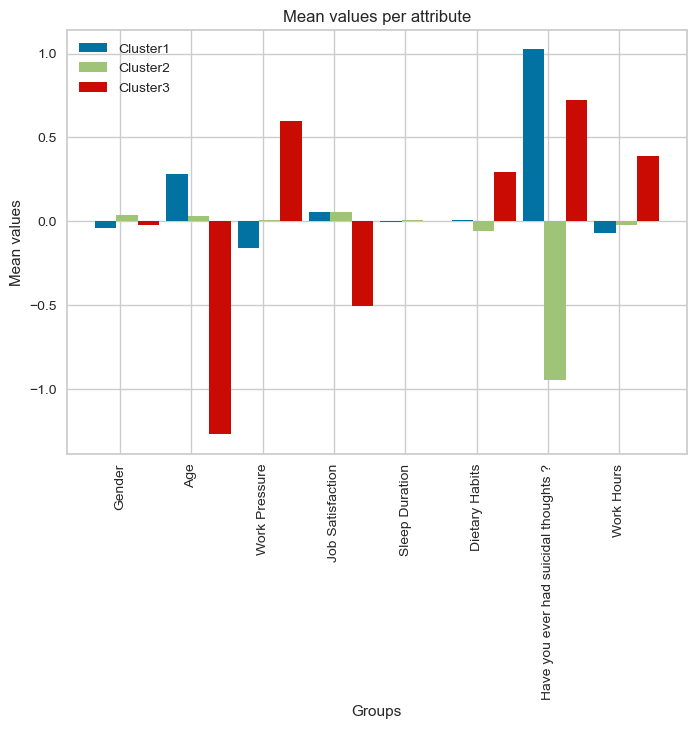

In [343]:
X = cluster1.keys()[:8]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, cluster1_mean_p1, 0.3, label = 'Cluster1')
plt.bar(X_axis + 0.1, cluster2_mean_p1, 0.3, label = 'Cluster2')
plt.bar(X_axis + 0.4, cluster3_mean_p1, 0.3, label = 'Cluster3')

plt.xticks(X_axis, X, rotation='vertical')
plt.xlabel("Groups")
#plt.subplots_adjust(bottom=0.1)
plt.ylabel("Mean values")
plt.title("Mean values per attribute")
plt.legend()
plt.show()

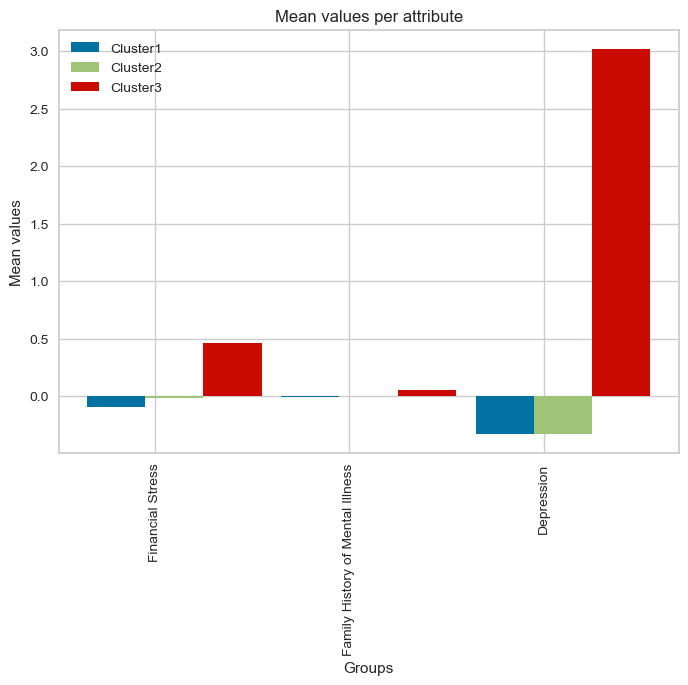

In [344]:
cluster1_mean_p2 = cluster1_mean[8:-2]
cluster2_mean_p2 = cluster2_mean[8:-2]
cluster3_mean_p2 = cluster3_mean[8:-2]

X = cluster1.keys()[8:-2]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, cluster1_mean_p2, 0.3, label = 'Cluster1')
plt.bar(X_axis + 0.1, cluster2_mean_p2, 0.3, label = 'Cluster2')
plt.bar(X_axis + 0.4, cluster3_mean_p2, 0.3, label = 'Cluster3')

plt.xticks(X_axis, X, rotation='vertical')
plt.xlabel("Groups")
plt.ylabel("Mean values")
plt.title("Mean values per attribute")
plt.legend()
plt.show()

NameError: name 'pd' is not defined